<a href="https://colab.research.google.com/github/csnobs/ETH-FDD-W4-flappy-bird-project/blob/main/w4_flappy_bird_project_student_cn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flappy Bird with PPO

Remember Flappy Bird? Same idea, but this time *you* teach the bird to fly —
with PPO — on a clean little discrete-grid version of the game.

Your bird has a height and a vertical velocity; obstacles march toward it one
column per step, each with a gap at some height. You get three inputs — no
flap, weak flap, strong flap — and the strong flap is *noisy*: its actual
impulse is the nominal one plus a random deviation. Welcome to imperfect
thrusters.

Under the hood this is not (just) a game. It is an underactuated
single-degree-of-freedom system with impulsive control: think vertical
hopper, or a lander with an on/off thruster. Gravity pulls continuously, the
controller can only push upwards in discrete kicks, and the strong kick does
not deliver exactly what the datasheet promises. The effort cost is
propellant — so flap wisely.

In this project, we work with two instances of this setup. The optimal value
of each state is fixed by the Bellman equation — one equation per state. On
`small` the mesh is coarse enough that those equations fit in a table, so you
get the exact optimal value function `V*` and policy `pi*` in about two
seconds. On that instance you will not be comparing PPO against a baseline —
you will be comparing it against the optimum. That's the fun part. `large` is
the same problem on a finer grid. Same physics in the continuum limit, but
roughly `1e17` states: you can no longer store a number per state, so you
cannot solve the Bellman equation exactly. Function approximation is the only
tool left. Time to earn your keep.

## What you hand in

| | |
|---|---|
| **3 implementation tasks** | the load-bearing pieces of PPO |
| **3 calibration tasks** | hyper-parameters you **compute**, not guess |
| **1 tuning table** | a written hypothesis *before* every run |

Alongside these compulsory submissions, you can explore the concept of Domain Randomization as a bonus!

Everywhere you are expected to write something is marked with a 🎯. You will find 🎯 in both coding and markdown cells. In coding cells you code, in markdown cells you explain us your intuition and choices.

In the coding cells each blank is written as `???`, with a `# 🎯` comment on the same line saying exactly what belongs there. `???` is not valid Python, so a cell you have not filled in yet fails loudly rather than silently doing the wrong thing. Everything around the blanks — signatures, docstrings, and the self-checks that follow — is already written: leave it alone and fill in the gaps.

A training run takes 3-4 minutes. So you have got time for running enough seeds!


## Feel the control problem before the code

The bird is an **underactuated vertical hopper**: gravity pulls every step, you
can only kick **upwards**, and the strong kick is noisy. Before we load the
simulator modules, skim the schematic below, then use the playground to build
the right mental model.

At each step you choose one of three impulses:

| action | impulse | effort cost | effect |
|---|---|---|---|
| **no flap** | `0` | `0.0` | only gravity acts |
| **weak flap** | `+2` | `0.5` | deterministic upward kick |
| **strong flap** | `+3 + noise` | `0.7` | larger kick, but the noise is uniform in `[-1, +1]` |

Reward on a survived step is `1 − effort`. Crash when you meet a pipe outside
its gap. Watch how `(y, v)` evolve: position integrates the *old* velocity,
then velocity is updated by `v ← clip(v + u + noise − g)`.


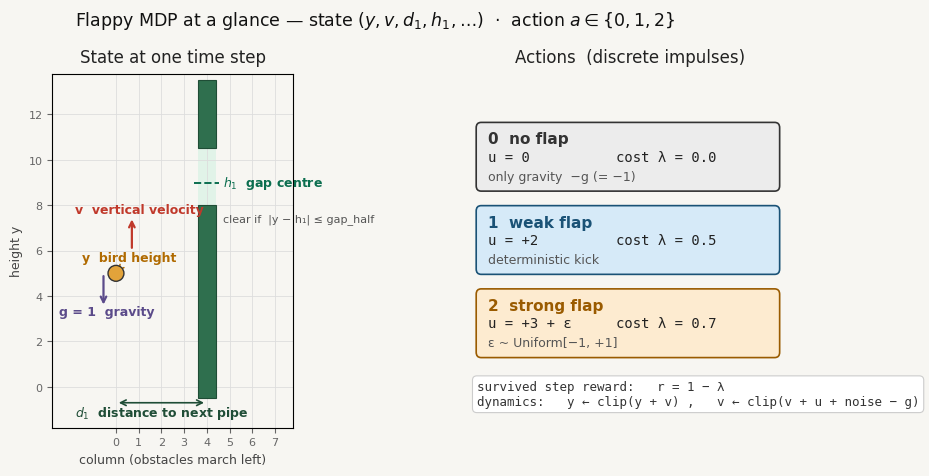

In [1]:
#@title States and Actions in a Nutshell { display-mode: "form" }
# Schematic of the MDP: what the state is, what the actions do.
# Pure matplotlib — no flappy imports required.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, Circle

X_g, Y_g = 8, 14
y_b, v_b, d1, h1, gap_half = 5, 1, 4, 9, 1
g = 1  # gravity (small instance)

fig = plt.figure(figsize=(10.5, 4.6), facecolor="#f7f6f2")
gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1.0], wspace=0.28)
ax = fig.add_subplot(gs[0, 0])
ax_a = fig.add_subplot(gs[0, 1])

# ---- left: annotated grid snapshot --------------------------------------
ax.set_xlim(-2.8, X_g - 0.2)
ax.set_ylim(-1.8, Y_g - 0.2)
ax.set_aspect("equal")
ax.set_facecolor("#f7f6f2")
ax.set_xticks(range(X_g))
ax.set_yticks(range(0, Y_g, 2))
ax.tick_params(labelsize=8, colors="#666")
ax.grid(True, color="#ddd", lw=0.6)
ax.set_xlabel("column (obstacles march left)", fontsize=9, color="#444")
ax.set_ylabel("height y", fontsize=9, color="#444")
ax.set_title("State at one time step", fontsize=12, pad=8, color="#222")

# pipe + gap
lo, hi = h1 - gap_half, h1 + gap_half
ax.add_patch(Rectangle((d1 - 0.4, -0.5), 0.8, lo + 0.5,
                        facecolor="#2f6f4e", edgecolor="#1f4d36", lw=0.8, zorder=2))
ax.add_patch(Rectangle((d1 - 0.4, hi + 0.5), 0.8, Y_g - hi - 1,
                        facecolor="#2f6f4e", edgecolor="#1f4d36", lw=0.8, zorder=2))
ax.add_patch(Rectangle((d1 - 0.4, lo - 0.5), 0.8, hi - lo + 1,
                        facecolor="#d9f2e4", edgecolor="none", alpha=0.7, zorder=1))

# bird
ax.add_patch(Circle((0, y_b), 0.35, facecolor="#e2a33a", edgecolor="#333", lw=1.0, zorder=5))

# y — left of the bird (clear of v / pipe)
ax.annotate(
    "y  bird height",
    xy=(0, y_b), xytext=(-1.5, y_b+0.7),
    fontsize=9, color="#b06a00", fontweight="bold",
    ha="left", va="center",
    arrowprops=dict(arrowstyle="->", color="#b06a00", lw=1.1),
)

# v — upward arrow; label higher in open space between bird and pipe
ax.annotate(
    "",
    xy=(0.7, y_b + 2.5), xytext=(0.7, y_b+1.0),
    arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.6),
)
ax.text(
    -1.8, y_b + 2.5, "v  vertical velocity",
    fontsize=9, color="#c0392b", fontweight="bold", va="bottom", ha="left",
)

# g — downward gravity arrow
ax.annotate(
    "",
    xy=(-0.55, y_b - 1.5), xytext=(-0.55, y_b),
    arrowprops=dict(arrowstyle="->", color="#5b4b8a", lw=1.6),
)
ax.text(
    -2.5, y_b - 1.7, f"g = {g}  gravity",
    fontsize=9, color="#5b4b8a", fontweight="bold", va="center", ha="left",
)

# distance brace
ax.annotate("", xy=(d1, -0.70), xytext=(0, -0.70),
            arrowprops=dict(arrowstyle="<->", color="#1f4d36", lw=1.2))
ax.text(d1 / 2, -1.3, r"$d_1$  distance to next pipe", ha="center",
        fontsize=9, color="#1f4d36", fontweight="bold")

# gap centre
ax.plot([d1 - 0.55, d1 + 0.55], [h1, h1], color="#0b6e4f", lw=1.4, ls="--", zorder=3)
ax.text(d1 + 0.7, h1, r"$h_1$  gap centre", fontsize=9,
        color="#0b6e4f", fontweight="bold", va="center")
ax.text(d1 + 0.7, h1 - 1.6, "clear if  |y − h₁| ≤ gap_half",
        fontsize=8, color="#555", va="center")


# ---- right: actions ------------------------------------------------------
ax_a.set_xlim(0, 10)
ax_a.set_ylim(0, 10)
ax_a.axis("off")
ax_a.set_title("Actions  (discrete impulses)", fontsize=12, pad=8, color="#222")

actions = [
    ("0  no flap",     "u = 0",       "cost λ = 0.0",  f"only gravity  −g (= −{g})", "#ececec", "#333"),
    ("1  weak flap",   "u = +2",      "cost λ = 0.5",  "deterministic kick",         "#d6eaf8", "#1a5276"),
    ("2  strong flap", "u = +3 + ε",  "cost λ = 0.7",  "ε ~ Uniform[−1, +1]",        "#fdebd0", "#9a5b00"),
]

for i, (name, impulse, cost, note, face, edge) in enumerate(actions):
    y0 = 7.6 - i * 2.35
    ax_a.add_patch(FancyBboxPatch((0.4, y0 - 0.9), 9.1, 1.9,
                                   boxstyle="round,pad=0.02,rounding_size=0.15",
                                   facecolor=face, edgecolor=edge, lw=1.2))
    ax_a.text(0.75, y0 + 0.55, name, fontsize=11, fontweight="bold", color=edge, va="center")
    ax_a.text(0.75, y0 + 0.05, impulse, fontsize=10, color="#222", va="center",
              fontfamily="monospace")
    ax_a.text(4.6, y0 + 0.05, cost, fontsize=10, color="#222", va="center",
              fontfamily="monospace")
    ax_a.text(0.75, y0 - 0.5, note, fontsize=9, color="#555", va="center")

ax_a.text(0.4, 0.55,
          "survived step reward:   r = 1 − λ\n"
          f"dynamics:   y ← clip(y + v) ,   v ← clip(v + u + noise − g)",
          fontsize=9, color="#333", va="bottom",
          fontfamily="monospace",
          bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                    edgecolor="#ccc", lw=0.8))

fig.suptitle("Flappy MDP at a glance — state $(y, v, d_1, h_1, \\ldots)$  ·  action $a \\in \\{0,1,2\\}$",
             fontsize=12.5, y=1.02, color="#111")
#plt.show()
plt.savefig("flappy_mdp.png")


In [2]:
#@title Interactive Playground -- try the game yourself! { display-mode: "form" }
# Self-contained playground — matches the `small` instance physics used later.
# No flappy.* imports yet: this is only for intuition before Part 0.

from io import BytesIO
import numpy as np

try:
    from ipywidgets import Button, HBox, VBox, HTML, Image, IntText
    from IPython.display import display
except ImportError as exc:
    raise ImportError("ipywidgets is required for the playground") from exc

# --- small-instance constants (same numbers as Const.small) ---------------
X, Y, V_MAX, G_GRAV = 8, 14, 2, 1
U = (0, 2, 3)                 # no / weak / strong
LAM = (0.0, 0.5, 0.7)
V_DEV, D_MIN, GAP = 1, 4, 3
S_H = (5, 9, 13)
GAP_HALF = (GAP - 1) // 2
ACTION_NAMES = ("no flap", "weak flap", "strong flap")


def _png(rgb):
    try:
        from PIL import Image as PILImage
        buf = BytesIO()
        PILImage.fromarray(rgb).save(buf, format="PNG")
        return buf.getvalue()
    except Exception:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(4, 5), dpi=80)
        ax.imshow(rgb, interpolation="nearest")
        ax.set_axis_off()
        buf = BytesIO()
        fig.savefig(buf, format="png", bbox_inches="tight", pad_inches=0.05)
        plt.close(fig)
        return buf.getvalue()


def _render(y, v, d1, h1, scale=8):
    """Render the discrete grid. scale = pixels per cell (keep cells square)."""
    rgb = np.empty((Y, X, 3), dtype=np.uint8)
    rgb[:] = (245, 245, 240)
    if 0 <= d1 < X:
        lo, hi = h1 - GAP_HALF, h1 + GAP_HALF
        rgb[:, d1] = (47, 111, 78)
        rgb[max(0, lo) : min(Y, hi + 1), d1] = (217, 242, 228)
    yy = int(np.clip(y, 0, Y - 1))
    rgb[yy, 0] = (226, 163, 58)
    if yy > 0:
        rgb[yy - 1, 0] = (200, 140, 40)
    rgb = np.repeat(np.repeat(rgb, scale, axis=0), scale, axis=1)
    return np.flipud(rgb)


class Playground:
    """Manual single-step Flappy on the small grid."""

    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)
        self.reset(seed)

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(int(seed))
        self.y = Y // 2
        self.v = 0
        self.d1 = X - 1
        self.h1 = int(self.rng.choice(S_H))
        self.t = 0
        self.ret = 0.0
        self.pipes = 0
        self.alive = True
        self.last = {
            "action": None, "u": 0, "noise": 0, "reward": 0.0,
            "note": "Choose an action. Obstacles advance one column per step.",
        }

    def step(self, a: int):
        if not self.alive:
            self.last["note"] = "Episode over — hit Reset."
            return
        a = int(a)
        u = U[a]
        noise = int(self.rng.integers(-V_DEV, V_DEV + 1)) if a == 2 else 0
        reward = 1.0 - LAM[a]

        passing = (self.d1 == 0) and (abs(self.y - self.h1) <= GAP_HALF)
        if passing:
            self.pipes += 1
            self.d1 = X - 1
            self.h1 = int(self.rng.choice(S_H))
        else:
            self.d1 -= 1

        # explicit Euler with the *old* velocity
        self.y = int(np.clip(self.y + self.v, 0, Y - 1))
        self.v = int(np.clip(self.v + u + noise - G_GRAV, -V_MAX, V_MAX))
        self.t += 1
        self.ret += reward

        crashed = (self.d1 == 0) and (abs(self.y - self.h1) > GAP_HALF)
        if crashed:
            self.alive = False
            note = f"CRASH at the pipe. Gap centred at h={self.h1}, you were at y={self.y}."
        else:
            noise_txt = f", noise={noise:+d}" if a == 2 else ""
            note = f"Applied {ACTION_NAMES[a]} (u={u}{noise_txt}). Reward this step: {reward:.1f}."
        self.last = {"action": a, "u": u, "noise": noise, "reward": reward, "note": note}


def launch_playground(seed=0, cell_px=8):
    game = Playground(seed=seed)
    # Exact pixel size of the grid image: (X * cell_px) × (Y * cell_px)
    img = Image(
        format="png",
        width=X * cell_px,
        height=Y * cell_px,
        layout={"width": f"{X * cell_px}px", "height": f"{Y * cell_px}px"},
    )
    info = HTML()
    seed_box = IntText(value=seed, description="seed", layout={"width": "140px"})

    def refresh():
        img.value = _png(_render(game.y, game.v, game.d1, game.h1, scale=cell_px))
        last = game.last
        status = "ALIVE" if game.alive else "DEAD"
        act = ACTION_NAMES[last["action"]] if last["action"] is not None else "—"
        noise_bit = "" if last["action"] != 2 else f" + noise {last['noise']:+d}"
        info.value = f"""
        <div style="font-family: ui-monospace, Menlo, monospace; line-height:1.45;">
          <b>state</b>&nbsp;&nbsp; y={game.y}&nbsp;&nbsp; v={game.v:+d}
            &nbsp;&nbsp; d₁={game.d1}&nbsp;&nbsp; h₁={game.h1}<br/>
          <b>score</b>&nbsp;&nbsp; t={game.t}&nbsp;&nbsp; return={game.ret:.1f}
            &nbsp;&nbsp; pipes={game.pipes}&nbsp;&nbsp; <b>{status}</b><br/>
          <b>last</b>&nbsp;&nbsp;&nbsp; {act}
            &nbsp;|&nbsp; u={last['u']}{noise_bit}
            &nbsp;|&nbsp; r={last['reward']:.1f}<br/>
          <span style="color:#444">{last['note']}</span><br/>
          <span style="color:#666; font-size:90%;">
            Tip: hold <b>no flap</b> — gravity drains v, then y falls.
            Strong flap helps, but noise can overshoot the gap.
          </span>
        </div>
        """

    def on_action(a):
        def _(_=None):
            game.step(a)
            refresh()
        return _

    def on_reset(_=None):
        game.reset(seed_box.value)
        refresh()

    btns = [
        Button(description="0 · no flap"),
        Button(description="1 · weak flap", button_style="info"),
        Button(description="2 · strong flap", button_style="warning"),
    ]
    for i, b in enumerate(btns):
        b.on_click(on_action(i))
    reset = Button(description="Reset", button_style="success")
    reset.on_click(on_reset)

    header = HTML(
        "<b>Manual playground</b> — you are the controller. "
        "Each click = one environment step on the <code>small</code> grid "
        f"({X}×{Y} cells)."
    )
    display(VBox([header, HBox([*btns, reset, seed_box]), info, img]))
    refresh()


launch_playground(seed=0, cell_px=8)

## Part 0 — Setup

The cells below write the provided modules to disk. Read them if you like —
the simulator is about 150 lines and it pays to know what is in it — but do
not modify them.

In [3]:
#@title 📥 0.1 — fetch the exercise files (run me) { display-mode: "form" }
import os, sys, subprocess

REPO_OWNER = "eth-fdd-fs26"
REPO_NAME  = "FDD-WE4-public"

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

if _in_colab():
    url = f"https://github.com/{REPO_OWNER}/{REPO_NAME}.git"   # public repo — no token needed
    if os.path.isdir(REPO_NAME):
        print("Repo already present — refreshing to latest…")
        res = subprocess.run(["git", "-C", REPO_NAME, "pull", "-q", url], capture_output=True, text=True)
        if res.returncode != 0:
            print("  (could not pull — using the existing copy)")
    else:
        print("Cloning the exercise repo…")
        res = subprocess.run(["git", "clone", "-q", url], capture_output=True, text=True)
        if res.returncode != 0:
            tail = (res.stderr.strip().splitlines() or ["(no message)"])[-1]
            print("  clone failed:", tail)

# Move to the repo root (the folder holding project/greenlight_lib.py) so imports resolve.
for _root in [REPO_NAME, ".", os.path.dirname(os.getcwd()), os.getcwd()]:
    if os.path.exists(os.path.join(_root, "project", "flappy")):
        os.chdir(_root)
        break
else:
    raise FileNotFoundError(
        f"project/flappy not found — the clone of {REPO_OWNER}/{REPO_NAME} did not land "
        "(see the message above). Check the Colab runtime has network access, then re-run this cell.")
sys.path.insert(0, os.path.join(os.getcwd(), "project"))   # make the helpers importable
print("Working directory:", os.getcwd(), "· helpers importable ✅")

Cloning the exercise repo…
Working directory: /content/FDD-WE4-public · helpers importable ✅


In [4]:
import os, sys, json, math
import numpy as np
import matplotlib.pyplot as plt
import torch
import importlib
import flappy.const, flappy.dynamics, flappy.env, flappy.features, flappy.networks
import flappy.student_impl, flappy.ppo, flappy.policies, flappy.evaluate
import flappy.dp, flappy.diagnostics, flappy.domain_randomization
for m in list(sys.modules):
    if m.startswith("flappy"):
        importlib.reload(sys.modules[m])

from flappy.const import Const
from flappy.env import VecFlappy
from flappy.ppo import Config, train, NetworkPolicy
from flappy.evaluate import run_episodes, heldout_seeds
from flappy.policies import LookaheadPolicy, ThresholdPolicy, RandomPolicy, TabularPolicy
from flappy.student_impl import shaped_reward, bootstrap_truncated
from flappy.features import scales, obs_dim
from flappy import dp, diagnostics, submission

# Names the TODO cells in Part 2 are written against.
from typing import Any

SMALL, LARGE = Const.small(), Const.large()
print(f"small: |S| = {SMALL.K:,}      large: |S| <= {LARGE.state_space_size_estimate():.3g}")
print("Part 2 TODOs are still stubs in student_impl — implement them there, then export.")


small: |S| = 7,770      large: |S| <= 1.33e+17
Part 2 TODOs are still stubs in student_impl — implement them there, then export.


## 🔍 Discretization explorer — what happens as the state space increases?

Even though our physics problem stays exactly the same, we can change how finely we chop up (discretize) the environment. Run the cell below to watch the grid (state space) increase.

The size of this grid determines one crucial thing: whether we can solve the Bellman optimality equation perfectly.To get a perfect (exact) solution, we need to calculate the optimal value, $V^*(s)$, for every single possible state $s$:

$$V^*(s) = \max_a \sum_{s'} P(s'\mid s,a) \Bigl[ R(s,a,s') + \gamma V^*(s') \Bigr].$$

If we can find $V^*$ for every state, we can easily extract the perfect strategy (the greedy policy, $\pi^*$):

$$\pi^*(s)=\arg\max_a \sum_{s'} P(s'\mid s,a) \Bigl[ R(s,a,s') + \gamma V^*(s') \Bigr].$$

Mathematically, calculating this is guaranteed to work—provided your computer has enough memory to store a value for every state in a massive "look-up table", and enough processing power to calculate every possible future outcome.

This is exactly what the explorer demonstrates:
- On small (approx. 7,770 states): The math is perfectly solvable. We can easily build a table with 7,770 rows, solve the equation for every state, and find the exact perfect policy $\pi^*$.
- The breaking point: As we make the grid finer, the total number of states multiplies rapidly (height $\times$ velocity $\times$ obstacles). Soon, the table becomes too massive to allocate in memory. We don't lose our exact solution because the physics changed; we lose it because the solution can no longer fit in a table.
- On large (approx. $10^{17}$ states): A table with 100 quadrillion rows is impossible. Our only option is to abandon the exact table $V^*(s)$ and replace it with a parametric approximator (like a neural network, $V_\theta(s)$). As we can't compute every possibility, we must sample the environment to estimate our updates.This necessary shift—from exact tables to estimated approximations—is exactly why we use algorithms like PPO in the rest of this notebook.

In [5]:
#@title 🔍 Discretisation explorer (small → large) { display-mode: "form" }
# Run AFTER the Part 0 import cell that defines SMALL / LARGE.
from io import BytesIO
from math import ceil
from ipywidgets import IntSlider, HBox, VBox, HTML, Image, Label
from IPython.display import display

MAX_ENUMERABLE = 5_000_000  # same cutoff as flappy.dp


def _refined_params(level: int) -> dict:
    """level=1 → 4×6, then alternate ×2 on X, Y up to level 8.

    Even steps double the width; odd steps (after 1) double the height:
      4×6 → 8×6 → 8×12 → 16×12 → 16×24 → 32×24 → 32×48 → 64×48
    Vertical physics (V_max, g, G) scales with Y; D_min scales with X.
    """
    level = int(np.clip(level, 1, 8))
    X, Y = 4, 6
    for step in range(2, level + 1):
        if step % 2 == 0:
            X *= 2
        else:
            Y *= 2

    kv = Y / 6.0
    V_max = max(1, int(round(kv)))
    g = V_max
    G = max(3, 2 * V_max + 1)  # odd gap height
    D_min = max(2, X // 2)
    half = (G - 1) // 2
    n_h = max(1, Y - 2 * half)
    M = ceil(X / D_min)
    n_sd = 1 + max(0, X - D_min)
    size = float(Y * (2 * V_max + 1) * X * (n_sd ** (M - 1)) * (n_h ** M))
    return dict(
        name=f"{X}×{Y}",
        level=level,
        X=X,
        Y=Y,
        V_max=V_max,
        g=g,
        G=G,
        D_min=D_min,
        n_h=n_h,
        M=M,
        size=size,
        exact=False,
    )


def _grid_png(p: dict, max_px=280) -> bytes:
    X, Y = p["X"], p["Y"]
    cell = int(np.clip(max(1, min(max_px // X, max_px // Y)), 1, 18))
    rgb = np.full((Y, X, 3), 245, dtype=np.uint8)
    for i in range(Y):
        for j in range(X):
            if (i + j) % 2 == 0:
                rgb[i, j] = (232, 232, 226)
    half = (p["G"] - 1) // 2
    h1 = Y // 2
    lo, hi = max(0, h1 - half), min(Y - 1, h1 + half)
    x_pipe = min(X - 1, max(1, X * 3 // 4))
    rgb[:, x_pipe] = (47, 111, 78)
    rgb[lo : hi + 1, x_pipe] = (217, 242, 228)
    yb = Y // 2
    rgb[yb, 0] = (226, 163, 58)
    if yb > 0:
        rgb[yb - 1, 0] = (200, 140, 40)
    rgb = np.repeat(np.repeat(np.flipud(rgb), cell, axis=0), cell, axis=1)
    try:
        from PIL import Image as PILImage
        from PIL import ImageDraw
        im = PILImage.fromarray(rgb)
        draw = ImageDraw.Draw(im)
        label = f"{X} x {Y}   cell={cell}px"
        draw.rectangle([2, 2, 2 + 7 * len(label), 16], fill=(255, 255, 255))
        draw.text((4, 3), label, fill=(40, 40, 40))
        buf = BytesIO()
        im.save(buf, format="PNG")
        return buf.getvalue()
    except Exception:
        fig, ax = plt.subplots(figsize=(4, 3.2), dpi=80)
        ax.imshow(rgb, interpolation="nearest")
        ax.set_title(f"{X} x {Y}")
        ax.set_axis_off()
        buf = BytesIO()
        fig.savefig(buf, format="png", bbox_inches="tight", pad_inches=0.05)
        plt.close(fig)
        return buf.getvalue()


def _fmt_size(n: float) -> str:
    return f"{n:,.0f}" if n < 1e4 else f"{n:.3g}"


def refinement_explorer():
    levels = [_refined_params(k) for k in range(1, 9)]
    pngs = [_grid_png(p) for p in levels]

    slider = IntSlider(
        value=1, min=1, max=8, step=1, description="refine",
        continuous_update=True, layout={"width": "420px"},
    )
    img = Image(format="png", value=pngs[0])
    stats = HTML()
    hint = Label()

    def _update(_=None):
        idx = int(slider.value) - 1
        p = levels[idx]
        img.value = pngs[idx]
        enumerable = p["size"] <= MAX_ENUMERABLE
        badge = (
            '<span style="background:#d4edda;color:#155724;padding:2px 8px;border-radius:4px;">'
            "Bellman solvable — exact V*, π*</span>"
            if enumerable else
            '<span style="background:#f8d7da;color:#721c24;padding:2px 8px;border-radius:4px;">'
            "Bellman not tabular — use PPO</span>"
        )
        size_note = "exact |S|" if p["exact"] else "upper bound on |S|"
        stats.value = f"""
        <div style="font-family:ui-monospace,Menlo,monospace;line-height:1.5;font-size:13px;">
          <b>instance</b>  {p['name']}  (level {p['level']}/8)<br/>
          <b>grid</b>      X={p['X']}, Y={p['Y']}, V_max={p['V_max']}, g={p['g']},
            G={p['G']}, M={p['M']}<br/>
          <b>|S_h|</b>     {p['n_h']} gap centres<br/>
          <b>|S|</b>       {_fmt_size(p['size'])}  <span style="color:#666">({size_note})</span><br/>
          <b>cutoff</b>    enumerable if |S| ≤ {MAX_ENUMERABLE:,}<br/>
          {badge}
        </div>
        """
        hint.value = {
            1: "Start tiny: 4×6 — every state fits in a table, Bellman is solvable.",
            2: "Double width → 8×6. Same idea, more columns.",
            3: "Double height → 8×12. Vertical physics scales with the mesh.",
            4: "Double width → 16×12. Still under the enumerable cutoff.",
            5: "Double height → 16×24. |S| crosses the cutoff — no more tabular Bellman.",
            6: "Double width → 32×24. The table you would need keeps growing.",
            7: "Double height → 32×48. Function approximation is the only option left.",
            8: "Double width → 64×48. Same continuum problem; Bellman fixed point is not a table.",
        }.get(p["level"], "Same continuous problem; only the discretisation changes.")

    slider.observe(_update, names="value")
    header = HTML(
        "<b>Discretisation explorer</b> — level 1 = <code>4×6</code>, then alternate "
        "×2 on width / height up to level 8. Same world; finer mesh."
    )
    display(VBox([header, slider, hint, HBox([img, stats])]))
    _update()


refinement_explorer()


### Our defined instances

Same proportions, different discretisation: `large` is `small` refined 8x
vertically and 4x horizontally. Notice the changes in the size of the state space and their values.

In [6]:
for C in (SMALL, LARGE):
    print(f"{C.name:6s} X={C.X:3d} Y={C.Y:4d} V_max={C.V_max:3d} g={C.g:2d} "
          f"G={C.G:3d} M={C.M} |S_h|={len(C.S_h):3d}   |S| <= {C.state_space_size_estimate():.3g}")

small  X=  8 Y=  14 V_max=  2 g= 1 G=  3 M=2 |S_h|=  3   |S| <= 2.52e+04
large  X= 32 Y= 112 V_max= 16 g= 8 G= 15 M=4 |S_h|= 98   |S| <= 1.33e+17


### Measure Delta before touching any hyper-parameter

**Delta = the mean number of steps between two obstacles.** It is the number
against which the discount factor, the rollout horizon and the GAE lambda all
have to be compared. The whole of Part 3 rests on it, so it gets measured, not
guessed.

We measure it from the *level geometry* rather than from `length / pipes`:
obstacles advance exactly one column per step, so their spacing in columns
**is** the number of steps between their arrivals. A policy that dies
immediately cannot bias it.

In [7]:
def measure_delta(C, n_envs=256, steps=400, seed=0):
    env = VecFlappy(C, n_envs, seed=seed, auto_reset=True)
    env.reset()
    rng = np.random.default_rng(seed)
    gaps = []
    for _ in range(steps):
        state, *_ = env.step(rng.integers(C.L, size=n_envs))
        g = state["d"][:, 1:][state["active"][:, 1:]]
        if g.size:
            gaps.append(g)
    return float(np.concatenate(gaps).mean())

DELTA = {C.name: measure_delta(C) for C in (SMALL, LARGE)}
print("Delta:", {k: round(v, 2) for k, v in DELTA.items()})

Delta: {'small': 4.8, 'large': 14.08}


### Watch the environment

The reference controller is `LookaheadPolicy`. To travel from bird height `y` to
the gap centre `h` in the `d` steps before the obstacle arrives you need a mean
vertical velocity of `(h - y) / d`, so it simply picks the input that brings the
next velocity closest to that target. Pure pursuit, discretised.

The plot below is a **time series**, not a game screen:

- **Top — `y`:** the bird’s **height** over time. The green band is the
  **safe gap** of the *next* pipe (it jumps when you pass one).
- **Bottom — `v`:** the bird’s **vertical velocity** (up is positive). Gravity
  pulls `v` down every step; flaps kick it up.


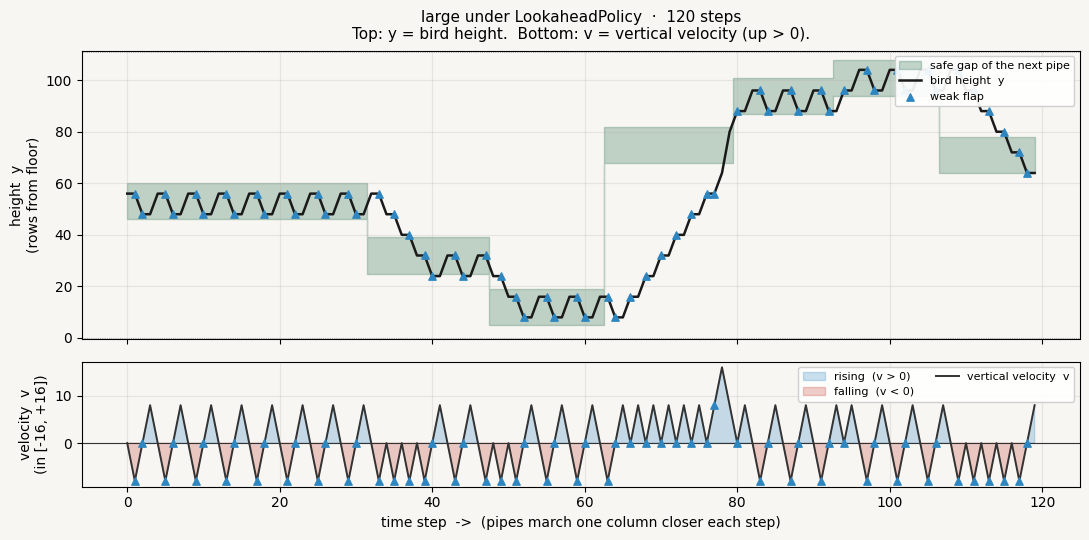

In [8]:
#@title Plot the Episode { display-mode: "form" }

def plot_episode(C, policy, seed=0, max_steps=120):
    """Time series of bird height y and vertical velocity v over one episode."""
    env = VecFlappy(C, 1, seed=0, auto_reset=False)
    s = env.reset([seed])
    policy.reset()

    ys, vs, los, his, acts = [], [], [], [], []
    while env.alive[0] and len(ys) < max_steps:
        a = int(policy.act(s)[0])
        ys.append(int(s["y"][0]))
        vs.append(int(s["v"][0]))
        h = int(s["h"][0, 0])
        los.append(h - C.gap_half)
        his.append(h + C.gap_half)
        acts.append(a)
        s, *_ = env.step(np.array([a]))

    t = np.arange(len(ys))
    acts = np.asarray(acts)
    ys = np.asarray(ys)
    vs = np.asarray(vs)

    fig, ax = plt.subplots(
        2, 1, figsize=(11, 5.5), sharex=True, height_ratios=[3, 1.3],
        facecolor="#f7f6f2",
    )
    for a_ in ax:
        a_.set_facecolor("#f7f6f2")

    # Top: bird height y
    ax[0].fill_between(
        t, los, his, alpha=0.28, step="mid", color="#2f6f4e",
        label="safe gap of the next pipe",
    )
    ax[0].plot(t, ys, color="#1a1a1a", lw=1.8, label="bird height  y")
    weak, strong = acts == 1, acts == 2
    if weak.any():
        ax[0].scatter(t[weak], ys[weak], s=28, c="#2e86c1", zorder=5,
                      label="weak flap", marker="^")
    if strong.any():
        ax[0].scatter(t[strong], ys[strong], s=36, c="#e67e22", zorder=5,
                      label="strong flap", marker="^")
    ax[0].axhline(0, color="#999", lw=0.6, ls=":")
    ax[0].axhline(C.Y - 1, color="#999", lw=0.6, ls=":")
    ax[0].set_ylim(-0.5, C.Y - 0.5)
    ax[0].set_ylabel("height  y\n(rows from floor)", fontsize=10)
    ax[0].legend(loc="upper right", fontsize=8, framealpha=0.92)
    ax[0].set_title(
        f"{C.name} under {type(policy).__name__}  ·  {len(ys)} steps\n"
        "Top: y = bird height.  Bottom: v = vertical velocity (up > 0).",
        fontsize=11, pad=8,
    )
    ax[0].grid(True, alpha=0.25)

    # Bottom: vertical velocity v
    ax[1].axhline(0, color="#333", lw=0.8)
    ax[1].fill_between(t, 0, vs, where=(vs >= 0), alpha=0.25, color="#2e86c1",
                       interpolate=True, label="rising  (v > 0)")
    ax[1].fill_between(t, 0, vs, where=(vs < 0), alpha=0.25, color="#c0392b",
                       interpolate=True, label="falling  (v < 0)")
    ax[1].plot(t, vs, color="#333", lw=1.4, label="vertical velocity  v")
    if weak.any():
        ax[1].scatter(t[weak], vs[weak], s=28, c="#2e86c1", marker="^", zorder=5)
    if strong.any():
        ax[1].scatter(t[strong], vs[strong], s=36, c="#e67e22", marker="^", zorder=5)
    ax[1].set_ylabel(f"velocity  v\n(in [-{C.V_max}, +{C.V_max}])", fontsize=10)
    ax[1].set_xlabel("time step  ->  (pipes march one column closer each step)", fontsize=10)
    ax[1].legend(loc="upper right", fontsize=8, framealpha=0.92, ncol=2)
    ax[1].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


plot_episode(LARGE, LookaheadPolicy(LARGE), seed=1)


### Interactive episode scrubber

The plot above is a trajectory summary. The widget below is a **frame-by-frame
replay**: roll out one episode once, then scrub the slider (or hit play) to see
the bird, the next gaps, and the action taken at every step.


In [9]:
#@title Visualise the Episode { display-mode: "form" }

from ipywidgets import IntSlider, Play, HBox, VBox, jslink, Output, HTML
from IPython.display import display, clear_output

ACTION_NAMES = {0: "no flap", 1: "weak", 2: "strong"}


def collect_episode_frames(C, policy, seed=0, max_steps=200):
    """Roll out one episode and keep every frame for scrubbing."""
    env = VecFlappy(C, 1, seed=0, auto_reset=False)
    state = env.reset([seed])
    policy.reset()
    frames = []
    while env.alive[0] and len(frames) < max_steps:
        action = int(policy.act(state)[0])
        frames.append({
            "t": int(state["t"][0]),
            "y": int(state["y"][0]),
            "v": int(state["v"][0]),
            "dx": state["dx"][0].copy(),
            "h": state["h"][0].copy(),
            "active": state["active"][0].copy(),
            "action": action,
            "pipes": int(env.pipes[0]),
            "ret": float(env.ret[0]),
        })
        state, reward, terminated, truncated, info = env.step(np.array([action]))
        frames[-1]["reward"] = float(reward[0])
        frames[-1]["terminated"] = bool(terminated[0])
        frames[-1]["truncated"] = bool(truncated[0])
    return frames


def draw_episode_frame(C, frame, ax):
    """Render one discrete-grid frame: bird at column 0, pipes at their dx."""
    ax.clear()
    ax.set_xlim(-0.5, C.X - 0.5)
    ax.set_ylim(-0.5, C.Y - 0.5)
    # Stretch x so pipe columns read farther apart on tall grids (e.g. LARGE).
    ax.set_aspect(0.35)
    ax.set_xlabel("column")
    ax.set_ylabel("height y")

    # Soft grid
    ax.set_xticks(range(C.X))
    ax.set_yticks(range(0, C.Y, max(1, C.Y // 8)))
    ax.grid(True, alpha=0.15)

    half = C.gap_half
    for i, (dx, h, active) in enumerate(zip(frame["dx"], frame["h"], frame["active"])):
        if not active or dx >= C.X:
            continue
        x = int(dx)
        lo = int(h) - half
        hi = int(h) + half
        # lower pipe
        if lo > 0:
            ax.add_patch(plt.Rectangle((x - 0.4, -0.5), 0.8, lo,
                                       color="#2f6f4e", alpha=0.85, zorder=2))
        # upper pipe
        if hi < C.Y - 1:
            ax.add_patch(plt.Rectangle((x - 0.4, hi + 0.5), 0.8, C.Y - hi - 0.5,
                                       color="#2f6f4e", alpha=0.85, zorder=2))
        # gap highlight
        ax.add_patch(plt.Rectangle((x - 0.4, lo - 0.5), 0.8, hi - lo + 1,
                                   facecolor="#d9f2e4", edgecolor="none",
                                   alpha=0.45, zorder=1))
        if i == 0:
            ax.axvline(x, color="#2f6f4e", lw=0.8, alpha=0.35, zorder=0)

    # bird
    ax.scatter([0], [frame["y"]], s=180, c="#e2a33a", edgecolors="k",
               linewidths=0.8, zorder=5, label="bird")
    # velocity arrow
    if frame["v"] != 0:
        ax.annotate("", xy=(0.15, frame["y"] + 0.35 * np.sign(frame["v"])),
                    xytext=(0.15, frame["y"]),
                    arrowprops=dict(arrowstyle="->", color="#333", lw=1.2))

    status = "CRASH" if frame.get("terminated") else (
        "TRUNCATED" if frame.get("truncated") else "alive")
    ax.set_title(
        f"{C.name}  |  t={frame['t']}  |  action={ACTION_NAMES[frame['action']]}  "
        f"|  v={frame['v']:+d}  |  pipes={frame['pipes']}  |  {status}"
    )


def interactive_episode(C, policy, seed=1, max_steps=160):
    """ipywidgets scrubber over a recorded episode."""
    frames = collect_episode_frames(C, policy, seed=seed, max_steps=max_steps)
    if not frames:
        print("episode produced no frames")
        return

    play = Play(value=0, min=0, max=len(frames) - 1, step=1, interval=120,
                description="Play")
    slider = IntSlider(value=0, min=0, max=len(frames) - 1, step=1,
                       description="step", continuous_update=True,
                       layout={"width": "60%"})
    jslink((play, "value"), (slider, "value"))

    out = Output()
    fig, ax = plt.subplots(figsize=(10, 4.2))
    plt.close(fig)  # keep the figure managed by the widget output only

    def _redraw(change=None):
        idx = int(slider.value)
        with out:
            clear_output(wait=True)
            draw_episode_frame(C, frames[idx], ax)
            display(fig)

    slider.observe(_redraw, names="value")
    header = HTML(
        f"<b>Interactive scrubber</b> — {type(policy).__name__} on "
        f"<code>{C.name}</code>, seed={seed}, {len(frames)} frames. "
        "Use the slider or play."
    )
    display(VBox([header, HBox([play, slider]), out]))
    _redraw()


interactive_episode(LARGE, LookaheadPolicy(LARGE), seed=1)

## Part 1 — The exact optimum

On `small` the state space can be enumerated, so value iteration returns `V*`
and `pi*` **exactly**.

Note that gamma has to lie strictly inside `(0, 1)`. That is not fussiness:
surviving earns `+1` per step, potentially forever, so the undiscounted
problem has unbounded value. **Gamma is what makes the problem well posed**
before it is anything else.

In [10]:
kernel = dp.build_kernel(SMALL)
V_star, pi_star = dp.value_iteration(kernel, gamma=0.99)
J_star = dp.expected_return(kernel, V_star)
print(f"|S| = {kernel.K:,}   J* = {J_star:.3f}   (upper bound 1/(1-g) = {1/0.01:.0f})")

|S| = 7,770   J* = 72.605   (upper bound 1/(1-g) = 100)


### Gamma is not an optimiser knob: it changes the problem

Recompute `pi*` under two different discounts and count the states where the
two optima disagree. If changing gamma changes the *optimum*, then choosing
gamma is choosing which problem you are solving — not how well you solve it.

In [11]:
_, pi_low  = dp.value_iteration(kernel, gamma=0.50)
_, pi_high = dp.value_iteration(kernel, gamma=0.99)
live = ~kernel.terminal
print(f"pi*(g=0.5) and pi*(g=0.99) disagree on {100*(pi_low[live] != pi_high[live]).mean():.1f}% of states")

pi*(g=0.5) and pi*(g=0.99) disagree on 22.8% of states


### The landscape PPO has to cross

Read this table carefully before going on.

In [12]:
class Always:
    def __init__(self, a): self.a = a
    def reset(self): pass
    def act(self, s): return np.full(s["y"].shape[0], self.a)

rows = [("never flap", Always(0)), ("always weak", Always(1)), ("random", RandomPolicy(SMALL, 0)),
        ("threshold", ThresholdPolicy(SMALL)), ("lookahead", LookaheadPolicy(SMALL)),
        ("DP optimal", TabularPolicy(kernel, pi_star))]
print(f"{'policy':<14} {'length':>10} {'pipes':>8} {'discounted J':>14}")
for name, p in rows:
    s = run_episodes(SMALL, p, np.arange(1000), gamma=0.99, batch_size=1000).summary()
    print(f"{name:<14} {s['length']:10.1f} {s['pipes']:8.2f} {s['discounted_return']:14.2f}")

policy             length    pipes   discounted J
never flap            7.0     0.00           6.79
always weak           9.8     0.53           4.64
random                9.3     0.44           5.33
threshold            16.5     1.80          10.68
lookahead            34.3     5.19          20.54
DP optimal          733.6   139.45          72.19


**"Never flap" beats both "random" and "always flap".** That is not a bug: the
effort cost is paid immediately while survival pays out later. Starting from a
near-random policy the gradient therefore points *towards* the collapse, and
escaping it means learning to flap **selectively** — a structured behaviour,
not "more" or "less".

This is a genuine deceptive optimum and it is deliberately left in place. If
you see the flap rate go to zero during training, you have not found a bug:
you have fallen into the basin.

## Part 2 — Implementing PPO

The training loop itself (rollouts, buffer, logging, checkpoints) is already wired up. Your job is to fill in the three pieces the loop calls into:

| Task | Function | What you decide |
|------|----------|-----------------|
| 1 | `build_observation` | which state features the network sees, and how they are scaled |
| 2 | `compute_gae` | GAE advantages / returns from a truncated rollout |
| 3 | `ppo_loss` | clipped surrogate + value loss + entropy, plus the KL metric |

After the three stubs, a short test cell checks contracts. A following cell patches your functions into `flappy.student_impl` so later `train(...)` calls pick them up. Run both before moving on.


### 🎯 Task 1 — `build_observation`

Choose **which** quantities the network sees and **how** they are scaled. The
full state is `(y, v, d_1..d_M, h_1..h_M)`; the environment hands it to you
already enriched with `dx` (absolute distances), `dy` (`h_i - y`) and
`active`.

Contract: `(N, obs_dim)` float32, using the **fixed** constants in
`features.scales`. No running statistics: they would couple every run to its
own history and make checkpoints unportable.

The `"minimal"` baseline sees only `(v, dy_0)` and *almost* works — it is
written out for you below as a worked example. Run it, watch where it fails,
then decide how much preview to add. That experiment is the exercise; the code
is four lines.

**Five blanks**, all in the `"full"` branch: two scalings for the bird itself,
and three columns per previewed obstacle.


In [13]:
# 🎯 TASK 1 — fill in the five ??? below.
def _build_observation(state: dict[str, np.ndarray], C: Const, cfg: Any) -> np.ndarray:
    """Map the ground-truth state to the network input.

    Parameters
    ----------
    state
        The dict returned by :meth:`flappy.env.VecFlappy.state_dict`:
        ``y (N,)``, ``v (N,)``, ``d (N, M)``, ``h (N, M)``, plus the derived
        ``dx (N, M)`` absolute distances, ``dy (N, M)`` gap offsets
        ``h_i - y``, and ``active (N, M)``. Empty obstacle slots report
        ``dx = X`` and ``dy = 0``, so carry ``active`` if you use them --
        otherwise an empty slot is indistinguishable from a genuinely
        distant obstacle.
    cfg
        Carries ``obs_mode`` and ``n_preview``. Whatever you return here
        must have the width that :func:`flappy.features.obs_dim` reports for
        that config, or the network will be built with the wrong input size.

    Returns
    -------
    ``(N, obs_dim)`` float32.

    Notes
    -----
    Use the fixed constants in :func:`flappy.features.scales` and nothing
    else. A running normaliser would couple every run to its own history and
    make checkpoints unportable -- it is a silent-bug factory that teaches
    nothing about control.

    The ``"minimal"`` baseline sees only ``(v, dy_0)``. It almost works.
    Run it, watch where it fails, then decide how much preview to add: that
    experiment is the exercise, not the code.
    """
    s = scales(C)
    y = ???   # 🎯 the bird height, re-centred on mid-grid ((C.Y - 1) / 2) then scaled by s["y"]
    v = ???   # 🎯 the vertical velocity, scaled by s["v"]

    if cfg.obs_mode == "minimal":
        dy0 = state["dy"][:, 0] / s["dy"]
        return np.stack([v, dy0], axis=1).astype(np.float32)

    if cfg.obs_mode != "full":
        raise ValueError(f"unknown observation mode {cfg.obs_mode!r}")

    P = min(cfg.n_preview, C.M)
    cols = [y, v]
    for i in range(P):
        cols.append(???)   # 🎯 obstacle i's absolute distance dx, scaled by s["dx"]
        cols.append(???)   # 🎯 obstacle i's gap offset dy, scaled by s["dy"]
        # 🎯 the activity flag as a float. It matters: without it an empty slot's
        #    sentinel distance is indistinguishable from a genuinely far obstacle.
        cols.append(???)
    return np.stack(cols, axis=1).astype(np.float32)


SyntaxError: invalid syntax (776257310.py, line 36)

### 🎯 Task 2 — `compute_gae`

$$\delta_t = r_t + \gamma V(s_{t+1})(1 - d_t) - V(s_t)
\qquad
A_t = \delta_t + \gamma\lambda (1 - d_t) A_{t+1}$$

A backward recursion. The mask `(1 - d_t)` has to appear **twice**: once in
the TD error, once in the accumulation. Drop one and credit leaks across
episode boundaries — and the learning curve will not tell you.

**Three blanks.** The loop, the accumulator and `next_value` are already set up;
you write the two lines of the recursion and the returns the critic regresses on.

In [ ]:
# 🎯 TASK 2 — fill in the three ??? below.
def _compute_gae(
    rewards: np.ndarray,
    values: np.ndarray,
    dones: np.ndarray,
    last_value: np.ndarray,
    gamma: float,
    lam: float,
) -> tuple[np.ndarray, np.ndarray]:
    """GAE(lambda) over a truncated rollout.

    Parameters
    ----------
    rewards, values, dones
        ``(T, N)``. ``dones[t]`` marks that the episode ended *on* step
        ``t``, so step ``t + 1`` belongs to a new episode.
    last_value
        ``(N,)`` value of the state following the final step.

    Returns
    -------
    advantages, returns
        Both ``(T, N)``.

    Notes
    -----
    ``delta_t = r_t + gamma * V(s_{t+1}) * (1 - done_t) - V(s_t)``
    ``A_t     = delta_t + gamma * lam * (1 - done_t) * A_{t+1}``

    The credit horizon is ``1 / (1 - gamma * lam)`` steps; calibration
    exercise C3 in the notebook asks for that number explicitly and
    compares it against the measured spacing between obstacles.
    """
    T, N = rewards.shape
    advantages = np.zeros((T, N), dtype=np.float64)
    last_gae = np.zeros(N, dtype=np.float64)
    for t in reversed(range(T)):
        next_value = last_value if t == T - 1 else values[t + 1]
        non_terminal = 1.0 - dones[t]
        delta = ???      # 🎯 the TD error: this step's reward plus the discounted
                         #    next_value, masked by non_terminal, minus values[t]
        last_gae = ???   # 🎯 the accumulation: delta plus gamma * lam * non_terminal
                         #    times the last_gae carried back from step t + 1
        advantages[t] = last_gae
    return advantages, ???   # 🎯 the returns the critic regresses on = advantages + values

### 🎯 Task 3 — `ppo_loss`

$$L = \underbrace{-\mathbb{E}\big[\min(\rho_t A_t,\ \mathrm{clip}(\rho_t, 1\pm\epsilon) A_t)\big]}_{\text{policy}}
+ c_v \underbrace{\tfrac12\mathbb{E}\big[(V - R)^2\big]}_{\text{value}}
- c_H \underbrace{\mathbb{E}[H]}_{\text{entropy}}$$

with $\rho_t = \exp(\log\pi_\text{new} - \log\pi_\text{old})$.

For the KL use Schulman's estimator $\mathbb{E}[(\rho - 1) - \log\rho]$, not
$-\mathbb{E}[\log\rho]$: the first is always non-negative and has far lower
variance. Calibration task C3 reads it off, so it has to be right.

**Six blanks.** Watch the signs: `pg_1` is already written and it carries the
minus that turns "maximise the surrogate" into "minimise a loss", so the
pessimistic branch of the clip is a `max`, not a `min`.

In [ ]:
# 🎯 TASK 3 — fill in the six ??? below.
def _ppo_loss(
    old_logprob: torch.Tensor,
    new_logprob: torch.Tensor,
    advantages: torch.Tensor,
    returns: torch.Tensor,
    new_value: torch.Tensor,
    entropy: torch.Tensor,
    cfg: Any,
) -> tuple[torch.Tensor, dict[str, float]]:
    """Clipped surrogate + value loss + entropy bonus.

    All inputs are flat ``(B,)`` tensors over one minibatch.

    Returns
    -------
    loss, metrics
        ``metrics`` carries the diagnostics the notebook's calibration
        exercises are read off: ``approx_kl`` drives the epoch count in C5,
        ``entropy`` and the flap rate drive the entropy coefficient in C4.
    """
    log_ratio = new_logprob - old_logprob
    ratio = ???   # 🎯 the probability ratio rho = exp(log pi_new - log pi_old)

    if cfg.norm_adv:
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    pg_1 = -advantages * ratio
    pg_2 = ???        # 🎯 the same product, but with ratio clamped to
                      #    [1 - cfg.clip_coef, 1 + cfg.clip_coef]
    pg_loss = ???     # 🎯 the pessimistic branch of the two, averaged over the batch

    v_loss = ???      # 🎯 half the mean squared error between new_value and returns
    ent = entropy.mean()

    loss = ???        # 🎯 policy loss + cfg.vf_coef * value loss - cfg.ent_coef * entropy

    with torch.no_grad():
        # 🎯 Schulman's low-variance KL estimator, mean of (rho - 1) - log rho.
        #    Always non-negative, unlike the naive -log_ratio.mean(). Call .item()
        #    on it so the metrics dict holds plain floats.
        approx_kl = ???
        clip_frac = ((ratio - 1.0).abs() > cfg.clip_coef).float().mean().item()

    return loss, {
        "policy_loss": pg_loss.item(),
        "value_loss": v_loss.item(),
        "entropy": ent.item(),
        "approx_kl": approx_kl,
        "clip_fraction": clip_frac,
    }

In [ ]:
import types

MY = types.SimpleNamespace(
    build_observation=_build_observation,
    shaped_reward=shaped_reward,
    bootstrap_truncated=bootstrap_truncated,
    compute_gae=_compute_gae,
    ppo_loss=_ppo_loss,
)

# GAE must not let credit cross a `done`.
r = np.zeros((6, 1)); v = np.zeros((6, 1)); d = np.zeros((6, 1))
d[2, 0] = 1.0; r[3, 0] = 100.0
adv, _ = MY.compute_gae(r, v, d, np.zeros(1), 0.99, 0.95)
assert np.allclose(adv[:3, 0], 0.0), f"credit leaked across the done: {adv[:3, 0]}"
assert abs(adv[3, 0] - 100.0) < 1e-9

# With no critic, lambda = 1 is the Monte Carlo return.
r = np.ones((8, 1)); d = np.zeros((8, 1)); d[-1, 0] = 1.0
adv, _ = MY.compute_gae(r, np.zeros((8, 1)), d, np.zeros(1), 0.9, 1.0)
assert np.allclose(adv[:, 0], [sum(0.9**k for k in range(8 - t)) for t in range(8)])

# At ratio 1 the surrogate is flat and the KL is zero.
lp = torch.randn(64)
loss, m = MY.ppo_loss(lp, lp.clone(), torch.randn(64), torch.zeros(64), torch.zeros(64),
                      torch.zeros(64), Config(ent_coef=0.0, vf_coef=0.0))
assert abs(m["approx_kl"]) < 1e-7 and abs(loss.item()) < 1e-5

# The observation width must match what the network will be built with.
from flappy.features import obs_dim
cfg0 = Config()
assert MY.build_observation(VecFlappy(SMALL, 4, seed=0).reset(), SMALL, cfg0).shape == \
       (4, obs_dim(SMALL, cfg0.obs_mode, cfg0.n_preview))

print("all tests pass — student_impl.py patched from Tasks 1-3")


In [ ]:
flappy.student_impl.build_observation = _build_observation
flappy.student_impl.compute_gae = _compute_gae
flappy.student_impl.ppo_loss = _ppo_loss

## Part 3 — Calibration you compute

No guessing here. Each task has the same shape:

> **compute → predict → verify with a short run → write the conclusion.**

Writing the conclusion before the verification, or the verification before the
computation, does not count.

### 🎯 C1 — Discount factor gamma

The decision that gets you past an obstacle pays out **Delta steps later**.
Fill in the table and find the two constraints, which pull in opposite
directions:

* **from below:** if `1/(1-gamma)` is not comfortably above Delta, the
  obstacle's reward is already drowned by the immediate survival reward by the
  time you decide. The agent learns to survive one instant longer, not to pass
  obstacles.
* **from above:** with `r ~ +1` per step the value to represent is
  `~ 1/(1-gamma)`. At gamma = 0.999 the value head, initialised to output
  about zero, has to reach 1000: the value loss dominates the gradient and the
  advantage variance blows up over a horizon longer than the episode itself.

In [ ]:
delta = DELTA["large"]
ep_len = run_episodes(LARGE, LookaheadPolicy(LARGE), np.arange(300), batch_size=300).summary()["length"]
print(f"Delta = {delta:.2f} steps   reference episode length = {ep_len:.0f} steps\n")
print(f"{'gamma':>8} {'1/(1-g)':>10} {'g^Delta':>10}   verdict")
for g in (0.8, 0.9, 0.95, 0.99, 0.999):
    h = 1/(1-g)
    verdict = ("horizon < Delta: cannot see the next obstacle" if h < delta else
               "horizon >> episode: value scale and variance blow up" if h > 4*ep_len else "ok")
    print(f"{g:8g} {h:10.1f} {g**delta:10.3f}   {verdict}")

In [ ]:
GAMMA = ???  # 🎯 C1 — your discount factor; justify it in the next cell

🎯 **Your conclusion (one line):** gamma = … because …

### 🎯 C2 — Rollout horizon T and number of environments N

The batch is `N x T`, but **the two knobs are not interchangeable**, and
anyone who looks only at the product confuses them.

* **T** governs how far credit can travel *inside* the batch. GAE is truncated
  at T; beyond that, credit only flows through the bootstrapped `V`, which is
  itself still being learned. If `T < Delta`, **no rollout ever contains a
  complete "decide to climb → pass the obstacle" cycle.**
* **N** governs gradient noise, which scales as `1/sqrt(N*T)`.

So: **T is dictated by the temporal structure of the task, N by your variance
budget.**

In [ ]:
print(f"constraint on T:  T >~ 2*Delta = {2*delta:.0f}")
print(f"{'N':>6} {'T':>5} {'batch':>7} {'useful events/batch':>21}")
for N, T in [(1024, 8), (512, 16), (256, 32), (128, 64), (64, 128)]:
    flag = "  <-- T < Delta: credit never arrives" if T < delta else ""
    print(f"{N:6d} {T:5d} {N*T:7d} {N*T/delta:21.0f}{flag}")

In [ ]:
ROLLOUT, NUM_ENVS = ???, ???  # 🎯 C2 — your choice of (T, N)

**Verify it.** At constant batch size, train with `(N,T) = (1024,8)`,
`(256,32)`, `(128,64)`. Compare the curves **against env steps**, not against
updates — otherwise the comparison means nothing.

🎯 **Your conclusion:** T = …, N = … because …

### 🎯 C3 — GAE lambda, and the learning rate the KL tells you to use

Two numbers, both read off a measurement rather than chosen by taste.

**Lambda.** The effective credit-assignment horizon is `1/(1 - gamma*lambda)`.
Compare it against Delta.

In [ ]:
g = 0.99
print(f"Delta = {delta:.1f}   ->   target [{delta:.0f}, {2*delta:.0f}]\n")
for lam in (0.9, 0.95, 0.99, 1.0):
    c = float("inf") if lam == 1 else 1/(1 - g*lam)
    print(f"lam={lam:<5g} 1/(1-g*lam) = {c:8.1f}   {'ok' if delta <= c <= 2*delta else ''}")

Notice what just happened: **lambda = 0.95, the value everybody copies out of
reference implementations, is exactly the one that aligns the credit horizon
with this task's obstacle spacing.** A universal default turned out to be
*derived* from a calculation about the specific problem. That is a better
lesson than a generic warning against copying defaults.

**Learning rate and epochs.** These are tuned **on a measurement, not on the
result**. Log the approximate KL per update; the target band is `0.01`–`0.02`.

* KL > 0.05 → the policy moves too far per update, the ratio leaves the
  clipping region and the collected data is no longer on-policy. **Reduce the
  epochs before touching the learning rate.**
* KL < 0.003 → you are wasting the batch. Increase the epochs.

This is not a theoretical exercise. The reference configuration of this
project was found exactly this way: at the customary `lr=3e-4, epochs=4` the
measured KL is about 0.0005, twenty times below the band, and the agent stalls
at 48% of the optimum. At `lr=3e-3, epochs=10` it reaches 94%. **The KL said so
before the return curve did.**

In [ ]:
for lr, ne in [(3e-4, 4), (3e-3, 10)]:
    cfg = Config(instance="small", total_steps=600_000, lr=lr, update_epochs=ne, seed=0)
    _, log = train(cfg, impl=MY, verbose=False)
    h = log.history; n = len(h)
    kl = np.median([r["approx_kl"] for r in h[n//4:3*n//4]])
    print(f"lr={lr:<8g} epochs={ne:<3d} median KL = {kl:.5f}   (target 0.01-0.02)")

In [ ]:
GAE_LAMBDA, LR, EPOCHS = ???, ???, ???  # 🎯 C3 — your choices

🎯 **Your conclusion:** lambda = … because …; lr = …, epochs = … because the measured KL is …

### One diagnostic to keep on screen: the flap rate

Not a task, but the single most useful number in the log. The policy has three
actions, so its maximum entropy is `ln 3 = 1.099` nats. With normalised
advantages (std ~ 1 by construction) the entropy coefficient reads as a direct
ratio: `ent_coef = 0.01` means the entropy bonus is worth about 1% of the
policy signal.

What matters in practice is the **flap rate**. If it falls below 0.02 or rises
above 0.6 within the first 50k steps, the run is dead — and you can see that in
three seconds of plotting instead of waiting for the return curve.

## Part 4 — Train, and measure yourself against the optimum

Three seeds. Not one.

In [ ]:
from dataclasses import replace
base = Config(instance="small", total_steps=2_000_000,
              gamma=GAMMA, gae_lambda=GAE_LAMBDA, lr=LR,
              update_epochs=EPOCHS, rollout=ROLLOUT, num_envs=NUM_ENVS)

nets, ratios = [], []
for seed in range(3):
    net, log = train(replace(base, seed=seed), impl=MY, verbose=False)
    cmp = diagnostics.compare_to_optimal(kernel, V_star, pi_star,
                                         NetworkPolicy(net, SMALL, base, impl=MY),
                                         gamma=0.99, seeds=heldout_seeds(200))
    nets.append(net); ratios.append(cmp.optimality_ratio)
    print(f"seed {seed}: J/J* = {100*cmp.optimality_ratio:5.1f}%   "
          f"agreement with pi* -- visited {100*cmp.agreement_visited:.1f}%, "
          f"uniform {100*cmp.agreement_uniform:.1f}%")
print(f"\nmean {100*np.mean(ratios):.1f}% +- {100*np.std(ratios, ddof=1)/np.sqrt(3):.1f}%")

Both agreement numbers are reported on purpose. The uniform one counts states
the agent never visits and is pessimistic; the visitation-weighted one is what
explains the return. **The gap between them is the lesson about which states a
policy actually has to get right.**

In [ ]:
vs, vhat = diagnostics.critic_vs_v_star(kernel, V_star, nets[0], SMALL, base)
counts = diagnostics.compare_to_optimal(kernel, V_star, pi_star,
                                        NetworkPolicy(nets[0], SMALL, base, impl=MY),
                                        gamma=0.99, seeds=heldout_seeds(200)).visit_counts
w = counts[~kernel.terminal]
fig, ax = plt.subplots(figsize=(5.5, 5.5))
sc = ax.scatter(vs, vhat, s=6, c=np.log10(w + 1), cmap="viridis", alpha=.7)
lim = [0, max(vs.max(), vhat.max())*1.05]
ax.plot(lim, lim, "k--", lw=1)
ax.set_xlabel("V* (exact)"); ax.set_ylabel("critic V")
ax.set_title("the critic is wrong mostly where it never goes")
plt.colorbar(sc, label="log10(1 + visits)"); plt.tight_layout(); plt.show()

## Part 5 — And now a solvable equation is no longer an option

Same problem, finer grid. Count the states.

In [ ]:
print(f"small: |S| = {SMALL.K:,}  ->  value iteration in ~2 s")
print(f"large: |S| <= {LARGE.state_space_size_estimate():.3g}")
print(f"       the value table alone would take {LARGE.state_space_size_estimate()*8/1e12:,.0f} TB\n")
try:
    dp.build_kernel(LARGE)
except MemoryError as e:
    print("build_kernel(LARGE) ->", e)

That is the curse of dimensionality, and it is not an assertion: it is a
number you just computed. From here on there is exactly one tool left on the
table — function approximation and policy gradients.

Redo the calibration: Delta is different, so gamma, lambda and T may be too.

### The native reward is not enough on `large`, and the reason is instructive

"Never flap" collects 31 steps of free survival before the first obstacle
arrives. With the native reward PPO falls into that basin every time. Raising
the entropy coefficient escapes it on roughly half the seeds. Making it
reliable takes a shaping term as well — which is what `shaped_reward`'s
`align_bonus` provides.

Measured over 2 seeds at 3M env steps:

| configuration | pipes | length |
|---|---:|---:|
| native reward | 0.01 ± 0.00 | 31 |
| `ent=0.05` | 12.0 ± 12.0 | 206 |
| **`ent=0.05`, `align=0.3`** | **41.8 ± 7.5** | 637 |
| `ent=0.05`, `align=1.0` | 31.9 ± 5.7 | 494 |
| `ent=0.15`, `align=1.0` | 33.4 ± 2.5 | 516 |
| lookahead (reference) | 13.4 | 226 |

Look at two things. A standard error of 12.0 on a mean of 12.0: with entropy
alone one seed escapes the basin and the other collapses. And the fact that
`align=0.3` beats `align=1.0` by ten pipes — the optimum in `align_bonus` is
**interior**. A bonus for hugging the gap centre, pushed too far, starts
competing with actually passing through it.

In [ ]:
cfg_large = Config.for_large()
net_l, log_l = train(cfg_large, impl=MY, verbose=True)

ref = run_episodes(LARGE, LookaheadPolicy(LARGE), heldout_seeds(300), batch_size=300).summary()
mine = run_episodes(LARGE, NetworkPolicy(net_l, LARGE, cfg_large, impl=MY),
                    heldout_seeds(300), batch_size=300).summary()
print(f"\n{'':12} {'pipes':>8} {'length':>11} {'flaps':>7}")
print(f"{'lookahead':12} {ref['pipes']:8.2f} {ref['length']:11.1f} {ref['flap_rate']:7.2f}")
print(f"{'PPO':12} {mine['pipes']:8.2f} {mine['length']:11.1f} {mine['flap_rate']:7.2f}")

## Part 6 — 🎯 The tuning table

🎯🎯 **Budget: 20 runs.** Before each one you fill in a row, with the prediction
written *before* you press enter.

| # | Hypothesis | What I change | Predicted metric | Measured metric | Conclusion |
|---|---|---|---|---|---|
| 1 | | | | | |

Rules:

1. one factor at a time;
2. any promising configuration is rerun on **3 seeds** with mean and standard
   error before you call it better;
3. **runs that refute your hypothesis are worth as much as runs that confirm
   it.**

With 20 runs and 3 seeds a grid search is impossible. That is precisely the
constraint that forces you to reason.

In [ ]:
def compare(tag, n_seeds=3, **kw):
    """One row of the table: mean +- standard error over several seeds."""
    out = []
    for seed in range(n_seeds):
        cfg = replace(Config.for_large(), seed=seed, **kw)
        net, _ = train(cfg, impl=MY, verbose=False)
        s = run_episodes(LARGE, NetworkPolicy(net, LARGE, cfg, impl=MY),
                         heldout_seeds(200), batch_size=200).summary()
        out.append(s["pipes"])
    out = np.array(out)
    print(f"{tag:<34} pipes {out.mean():7.2f} +- {out.std(ddof=1)/np.sqrt(n_seeds):5.2f}")
    return out

In [ ]:
# # 🎯 Uncomment and run this cell to compare the performance of different hyperparameters
# compare("gamma=0.95", n_seeds=3, gamma=0.95)

## 🎯 Bonus (optional) — Domain randomization

**Not graded but important concept for deployment of RL in real-world applications.**

So far, randomness enters through the **noise tape**: each episode seed fixes
the spawn draws, gap draws and strong-flap disturbances. That is **episodic
stochasticity**. The **physics** itself (`g`, `V_dev`, thrust, …) has stayed
constant so far.

**Domain randomization** resamples physics parameters at every episode reset.
The policy must work across a *family* of MDPs. That is the usual sim-to-real
trick: train on many perturbed simulators so deployment is less brittle.

So far we have considered the **`V_dev`** noise on strong flap to be ±1. In reality, our flappy bird might at times fly through a windless doldrum where **`V_dev`**=±0 or through windy cyclones where **`V_dev`**=±2. The demo below randomizes **`V_dev`** (strong-flap noise half-width): both
domains stay playable, and you can see nominal overfitting vs DR robustness.

**Optional exercise 🎯:** implement `sample_episode_physics` so it returns a
fresh `Const`, drawn from `DRConfig`. Derive the draw from the episode-seed RNG so episodes stay reproducible.

In [ ]:
from flappy.domain_randomization import DRConfig, DomainRandomizedVecFlappy
import flappy.ppo as _ppo_mod

def sample_episode_physics(
    base: Const, rng: np.random.Generator, dr: DRConfig
) -> Const:
    """Sample one episode's physics from the episode-seed RNG.

    Parameters
    ----------
    base
        Nominal ``Const`` for this run (e.g. ``LARGE``). Randomization is
        applied on top of these values.
    rng
        NumPy generator seeded by the episode seed, so the same episode
        always draws the same physics.
    dr
        Which knobs to randomize: ``vertical_scales`` (joint multiplier on
        ``g``, ``V_max``, ``U_weak``, ``U_strong``).

    Returns
    -------
    Const
        A copy of ``base`` with the sampled knobs filled in, or ``base``
        itself if nothing was randomized. The ``name`` field is tagged with
        the drawn scale / ``V_dev`` for logging.
    """
    kw: dict = {}
    name = base.name

    if dr.vertical_scales is not None:
        s = int(rng.choice(dr.vertical_scales))
        kw.update(
            # 🎯 Update the base variables with the generated multiplier value
            g= ???,
            V_max= ???,
            U_weak= ???,
            U_strong= ???
        )
        name = f"{name}_s{s}"

    if dr.v_dev_choices is not None:
        v_dev = int(rng.choice(dr.v_dev_choices))
        kw["V_dev"] = v_dev
        name = f"{name}_vd{v_dev}"

    if not kw:
        return base
    kw["name"] = name
    return replace(base, **kw)

flappy.domain_randomization.DomainRandomizedVecFlappy._sample_episode_physics = staticmethod(
    sample_episode_physics
)

In [ ]:
def train_with_dr(cfg, dr_cfg: DRConfig, impl=None, verbose: bool = True):
    """PPO training with domain-randomized physics (bonus only)."""
    _Vec = _ppo_mod.VecFlappy

    def _factory(C, num_envs, seed=0, auto_reset=True):
        return DomainRandomizedVecFlappy(
            C, num_envs, dr_cfg=dr_cfg, seed=seed, auto_reset=auto_reset
        )

    _ppo_mod.VecFlappy = _factory
    try:
        return train(cfg, impl=impl, verbose=verbose)
    finally:
        _ppo_mod.VecFlappy = _Vec

### Brittleness demo

**Setup.** Train on nominal `V_dev = 1`, evaluate on `V_dev ∈ {0, 1, 2}`.
Then retrain with DR over the same set.

Off by default (`RUN_DR_BONUS = False`). Flip the flag to run (~1–2 min). If your DR training results are not an improvement over the nominal training results, revisit your solution in the `sample_episode_physics` method above.


In [ ]:
RUN_DR_BONUS = False  # 🎯 Set True to run the ablation below

# Evaluation domains: same grid, different strong-flap noise.
EVAL_VDEVS = (0, 1, 2)


def _eval_pipes(net, C_eval, cfg, seeds, label: str) -> float:
    s = run_episodes(
        C_eval,
        NetworkPolicy(net, C_eval, cfg, impl=MY),
        seeds,
        batch_size=min(200, len(seeds)),
    ).summary()
    print(f"{label:<36} pipes {s['pipes']:6.2f}")
    return s["pipes"]


if RUN_DR_BONUS:
    dr_cfg = DRConfig(v_dev_choices=EVAL_VDEVS)
    cfg_bonus = replace(
        Config(),
        instance="small",
        total_steps=500_000,
        num_envs=64,
        seed=0,
        ent_coef=0.05,
        align_bonus=0.3,
    )
    seeds = heldout_seeds(100)

    print("=== nominal training (fixed V_dev = 1) ===")
    net_nom, _ = train(cfg_bonus, impl=MY, verbose=False)
    print("\n--- evaluate nominal policy ---")
    for vd in EVAL_VDEVS:
        C_eval = replace(SMALL, V_dev=vd, name=f"small_vd{vd}")
        _eval_pipes(net_nom, C_eval, cfg_bonus, seeds, f"nominal train -> eval V_dev={vd}")

    print("\n=== DR training (V_dev ~ Uniform{0,1,2} each episode) ===")
    net_dr, log_dr = train_with_dr(cfg_bonus, dr_cfg, impl=MY, verbose=False)
    last = log_dr.history[-1]
    print(
        f"(train pulse) ep_pipes={last.get('ep_pipes', float('nan')):.2f}  "
        f"flap_rate={last.get('flap_rate', float('nan')):.3f}  "
        f"— if flap_rate≈0 and pipes≈0, you hit the never-flap collapse"
    )
    print("\n--- evaluate DR policy ---")
    for vd in EVAL_VDEVS:
        C_eval = replace(SMALL, V_dev=vd, name=f"small_vd{vd}")
        _eval_pipes(net_dr, C_eval, cfg_bonus, seeds, f"DR train      -> eval V_dev={vd}")
else:
    print("DR bonus demo skipped (RUN_DR_BONUS = False). Part 7 is unaffected.")


## Part 7 — 🎯 Hand-in

**This notebook is the hand-in.** Nothing else: no weights, no checkpoint, no
extra file. You save it and submit it.

We run it in the course repository. The harness reads your notebook, pulls out
`build_observation`, `compute_gae`, `ppo_loss` and `FINAL_CONFIG`, and
**retrains from scratch** over several seeds on the `large` instance.

Declare the configuration you want us to train:

In [ ]:
# 🎯🎯 Declare your final config here by replacing the hyperparameters below
FINAL_CONFIG = Config.for_large(gamma=GAMMA, gae_lambda=GAE_LAMBDA, lr=LR,
                               update_epochs=EPOCHS, rollout=ROLLOUT,
                               num_envs=NUM_ENVS)  # everything else comes from Config.for_large()

Now check it. This runs exactly the validation the harness runs, on the names
you have defined in this session.

In [ ]:
sub = submission.collect(globals())
print("required functions:", ", ".join(submission.REQUIRED_FUNCTIONS))
print("config:", sub.config.instance, f"{sub.config.total_steps:,} env steps",
      f"(budget {submission.MAX_ENV_STEPS:,})")
print("gamma", sub.config.gamma, "| lambda", sub.config.gae_lambda,
      "| lr", sub.config.lr, "| epochs", sub.config.update_epochs,
      "| T", sub.config.rollout, "| N", sub.config.num_envs)
print("\nsubmission is valid")

Finally, a dry run of what we will do to it: train once from your config and
score it on held-out seeds.

In [ ]:
net_s, log_s = train(sub.config, impl=sub.impl, verbose=False)
mine = run_episodes(LARGE, NetworkPolicy(net_s, LARGE, sub.config, impl=sub.impl),
                    heldout_seeds(50), batch_size=50).summary()
ref = run_episodes(LARGE, LookaheadPolicy(LARGE), heldout_seeds(50), batch_size=50).summary()
print(f"{'':12} {'pipes':>8} {'length':>11}")
print(f"{'lookahead':12} {ref['pipes']:8.2f} {ref['length']:11.1f}")
print(f"{'yours':12} {mine['pipes']:8.2f} {mine['length']:11.1f}")

The dry run above left `net_s` in memory. The next cell rolls out one episode
under that policy and replays it in an **interactive player** embedded right
here: press play, scrub through the episode, step frame by frame with the arrow
keys, or slow it down to watch a single pipe pass. The faint grid is the real
discrete state space — the bird occupies one cell of it and every obstacle moves
exactly one column per tick.

The same player is also written to `flappy_trained.html` next to the notebook,
so you can open or share it on its own.

In [ ]:
#@title Watch your trained agent { display-mode: "form" }
import base64
import html as _html
import json
from pathlib import Path

from IPython.display import HTML as _IPyHTML, display

def _episode_payload(C, policy, seed=1, max_steps=400, fps=12):
    """Roll out one episode and flatten it into a JSON-safe replay payload.

    Obstacles need a stable identity so the player can interpolate their motion
    between steps. ``t + dx`` is exactly that: an obstacle marches one column
    closer per step, so the sum is invariant while it is on screen.
    """
    if "collect_episode_frames" in globals():
        raw = collect_episode_frames(C, policy, seed=seed, max_steps=max_steps)
    else:
        env = VecFlappy(C, 1, seed=0, auto_reset=False)
        state = env.reset([seed])
        policy.reset()
        raw = []
        while env.alive[0] and len(raw) < max_steps:
            action = int(policy.act(state)[0])
            raw.append({
                "t": int(state["t"][0]), "y": int(state["y"][0]),
                "v": int(state["v"][0]), "dx": state["dx"][0].copy(),
                "h": state["h"][0].copy(), "active": state["active"][0].copy(),
                "action": action, "pipes": int(env.pipes[0]),
                "ret": float(env.ret[0]), "terminated": False, "truncated": False,
            })
            state, reward, terminated, truncated, _ = env.step(np.array([action]))
            raw[-1]["reward"] = float(reward[0])
            raw[-1]["terminated"] = bool(terminated[0])
            raw[-1]["truncated"] = bool(truncated[0])
    if not raw:
        raise RuntimeError("episode produced no frames")

    frames = []
    for fr in raw:
        t = int(fr["t"])
        obstacles = []
        for dx, h, active in zip(fr["dx"], fr["h"], fr["active"]):
            if not active or not (0 <= int(dx) < C.X):
                continue
            obstacles.append([t + int(dx), int(dx), int(h)])
        frames.append({
            "t": t,
            "y": int(fr["y"]),
            "v": int(fr["v"]),
            "a": int(fr["action"]),
            "p": int(fr["pipes"]),
            "r": round(float(fr["ret"]), 2),
            "dead": bool(fr.get("terminated", False)),
            "cut": bool(fr.get("truncated", False)),
            "o": obstacles,
        })
    return {
        "name": str(C.name), "X": int(C.X), "Y": int(C.Y),
        "gap_half": int(C.gap_half), "V_max": int(C.V_max),
        "fps": int(fps), "seed": int(seed),
        "policy": type(policy).__name__,
        "frames": frames,
    }


_PLAYER_TEMPLATE = r"""<meta charset="utf-8">
<style>
  :root {
    --ink: #22303c; --muted: #6b7d8c; --line: #dfe6ea;
    --card: #ffffff; --chip: #eef3f6;
  }
  * { box-sizing: border-box; }
  html, body { margin: 0; padding: 0; background: transparent; }
  body {
    font: 13px/1.45 ui-sans-serif, -apple-system, "Segoe UI", Roboto, sans-serif;
    color: var(--ink); padding: 6px;
  }
  .card {
    background: var(--card); border: 1px solid var(--line); border-radius: 12px;
    padding: 10px 12px 12px; max-width: 1000px; margin: 0 auto;
    box-shadow: 0 1px 2px rgba(16,32,45,.06);
  }
  .hud { display: flex; align-items: baseline; gap: 14px; flex-wrap: wrap;
         margin-bottom: 8px; }
  .score { font-size: 22px; font-weight: 700; letter-spacing: -.02em; }
  .score small { font-size: 11px; font-weight: 600; color: var(--muted);
                 text-transform: uppercase; letter-spacing: .08em; margin-left: 5px; }
  .stat { font-variant-numeric: tabular-nums; color: var(--muted); }
  .stat b { color: var(--ink); font-weight: 600; }
  .chip { display: inline-block; padding: 2px 9px; border-radius: 999px;
          font-weight: 600; font-size: 12px; background: var(--chip); }
  .chip.a0 { background: #e7edf1; color: #4d6072; }
  .chip.a1 { background: #fdf0d5; color: #8a6212; }
  .chip.a2 { background: #ffe0c2; color: #94480e; }
  .spacer { flex: 1 1 auto; }
  .badge { font-size: 11px; color: var(--muted); }
  .stage { position: relative; border-radius: 10px; overflow: hidden;
           border: 1px solid var(--line); line-height: 0; }
  canvas { display: block; width: 100%; height: __CANVAS_H__px; }
  .ctrls { display: flex; align-items: center; gap: 8px; margin-top: 9px; }
  button, select {
    font: inherit; color: var(--ink); background: #f6f9fb; cursor: pointer;
    border: 1px solid var(--line); border-radius: 8px; padding: 4px 10px;
  }
  button:hover, select:hover { background: #eef3f6; }
  button.primary { background: #2f6f4e; border-color: #2f6f4e; color: #fff;
                   min-width: 44px; }
  button.primary:hover { background: #275c41; }
  input[type=range] { flex: 1 1 auto; accent-color: #2f6f4e; min-width: 60px; }
  label.tog { display: inline-flex; align-items: center; gap: 5px;
              color: var(--muted); user-select: none; cursor: pointer; }
  .foot { margin-top: 7px; font-size: 11px; color: var(--muted); }
  .foot code { background: var(--chip); padding: 1px 5px; border-radius: 4px; }
</style>
<div class="card">
  <div class="hud">
    <div class="score"><span id="score">0</span><small>pipes</small></div>
    <div class="stat">step <b id="t">0</b></div>
    <div class="stat">v <b id="v">+0</b></div>
    <div class="stat">return <b id="ret">0.0</b></div>
    <span class="chip a0" id="act">no flap</span>
    <div class="spacer"></div>
    <div class="badge" id="meta"></div>
  </div>
  <div class="stage"><canvas id="cv"></canvas></div>
  <div class="ctrls">
    <button class="primary" id="play">&#9658;</button>
    <button id="restart" title="restart">&#8635;</button>
    <input type="range" id="scrub" min="0" max="1" value="0" step="1">
    <select id="speed" title="playback speed">
      <option value="0.5">0.5&times;</option>
      <option value="1" selected>1&times;</option>
      <option value="2">2&times;</option>
    </select>
    <label class="tog"><input type="checkbox" id="grid" checked> grid</label>
  </div>
  <div class="foot">
    <b>space</b> play/pause &middot; <b>&larr; &rarr;</b> single step &middot;
    the faint grid is the true discrete state space: the bird occupies one cell of a
    <code id="dims"></code> grid and every obstacle steps exactly one column per tick.
  </div>
</div>
<script>
(function () {
  "use strict";
  const P = __PAYLOAD__;
  const BIRD_SRC = __BIRD_SRC__;
  const BG_SRC = __BG_SRC__;

  const F = P.frames, N = F.length;
  const X = P.X, Y = P.Y, GH = P.gap_half, VM = Math.max(1, P.V_max);
  const PLAY_H = __PLAY_H__, GROUND_H = __GROUND_H__, CANVAS_H = __CANVAS_H__;
  const ACTION = ["no flap", "weak flap", "strong flap"];

  const cv = document.getElementById("cv");
  const ctx = cv.getContext("2d");
  const el = (id) => document.getElementById(id);
  el("dims").textContent = X + " x " + Y;
  el("meta").textContent = P.policy + " on " + P.name + " - seed " + P.seed +
                           " - " + N + " steps";
  el("scrub").max = String(N - 1);

  // Vertical breathing room so the bird is not clipped in row 0 or row Y-1.
  const PAD_T = 26, PAD_B = 10;
  let W = 900, ch = (PLAY_H - PAD_T - PAD_B) / Y, cw = W / X;

  function resize() {
    const rect = cv.getBoundingClientRect();
    W = Math.max(320, Math.round(rect.width));
    const dpr = Math.min(2.5, window.devicePixelRatio || 1);
    cv.width = Math.round(W * dpr);
    cv.height = Math.round(CANVAS_H * dpr);
    ctx.setTransform(dpr, 0, 0, dpr, 0, 0);
    // One spare column of margin so the bird, which lives in column 0, is not
    // clipped by the left edge.
    cw = W / (X + 1.7);
    draw();
  }

  // Column/row -> pixel. Row 0 is the floor, so y is flipped.
  const px = (col) => (col + 1.4) * cw;
  const xEdge = (col) => (col + 0.9) * cw;
  const py = (row) => PLAY_H - PAD_B - (row + 0.5) * ch;

  // ---- deterministic scenery -------------------------------------------
  let s = 20260808;
  const rnd = () => ((s = (s * 1103515245 + 12345) & 0x7fffffff) / 0x7fffffff);
  const SPAN = X * 2;                       // world width the scenery wraps over
  const clouds = [];
  for (let i = 0; i < 16; i++) {
    clouds.push({
      x: rnd() * SPAN,
      y: 0.06 + rnd() * 0.5,
      s: 0.55 + rnd() * 0.85,
      layer: i % 2 ? 0.30 : 0.15,
      a: i % 2 ? 0.85 : 0.5,
    });
  }

  let bird = null, bg = null;
  if (BIRD_SRC) { bird = new Image(); bird.onload = draw; bird.src = BIRD_SRC; }
  if (BG_SRC) { bg = new Image(); bg.onload = draw; bg.src = BG_SRC; }

  // ---- playback state ---------------------------------------------------
  let step = 0, alpha = 0, playing = true, speed = 1, endHold = 0, last = 0;
  const puffs = [], pops = [];
  let wingBeat = 0, wingPhase = 0;

  function frameAt(i) { return F[Math.max(0, Math.min(N - 1, i))]; }

  function interpolated() {
    const A = frameAt(step), B = frameAt(step + 1);
    const at_end = step >= N - 1;
    const t = at_end ? 0 : alpha;
    const by = A.y + (B.y - A.y) * t;
    const ma = new Map(), mb = new Map(), hh = new Map();
    for (const o of A.o) { ma.set(o[0], o[1]); hh.set(o[0], o[2]); }
    for (const o of B.o) { mb.set(o[0], o[1]); hh.set(o[0], o[2]); }
    const obs = [];
    const ids = new Set([...ma.keys(), ...mb.keys()]);
    for (const id of ids) {
      // An obstacle missing from one side is entering or leaving: extrapolate
      // by the one column it moves per step so it slides instead of popping.
      const a = ma.has(id) ? ma.get(id) : mb.get(id) + 1;
      const b = mb.has(id) ? mb.get(id) : ma.get(id) - 1;
      obs.push({ dx: a + (b - a) * t, h: hh.get(id) });
    }
    return { y: by, obs: obs, world: step + t, f: A };
  }

  // ---- painters ---------------------------------------------------------
  function roundRect(x, y, w, h, r) {
    r = Math.max(0, Math.min(r, Math.abs(w) / 2, Math.abs(h) / 2));
    ctx.beginPath();
    ctx.moveTo(x + r, y);
    ctx.arcTo(x + w, y, x + w, y + h, r);
    ctx.arcTo(x + w, y + h, x, y + h, r);
    ctx.arcTo(x, y + h, x, y, r);
    ctx.arcTo(x, y, x + w, y, r);
    ctx.closePath();
  }

  function paintSky(world) {
    if (bg && bg.complete && bg.naturalWidth) {
      const scale = Math.max(W / bg.naturalWidth, PLAY_H / bg.naturalHeight);
      const dw = bg.naturalWidth * scale, dh = bg.naturalHeight * scale;
      ctx.drawImage(bg, (W - dw) / 2, (PLAY_H - dh) / 2, dw, dh);
      return;
    }
    const g = ctx.createLinearGradient(0, 0, 0, PLAY_H);
    g.addColorStop(0, "#4a9fd4");
    g.addColorStop(0.55, "#7fc4e3");
    g.addColorStop(1, "#cfe9de");
    ctx.fillStyle = g;
    ctx.fillRect(0, 0, W, PLAY_H);

    // sun glow
    const sg = ctx.createRadialGradient(W * 0.82, PLAY_H * 0.18, 2,
                                        W * 0.82, PLAY_H * 0.18, PLAY_H * 0.45);
    sg.addColorStop(0, "rgba(255,246,214,.85)");
    sg.addColorStop(1, "rgba(255,246,214,0)");
    ctx.fillStyle = sg;
    ctx.fillRect(0, 0, W, PLAY_H);

    for (const c of clouds) {
      let cx = ((c.x - world * c.layer) % SPAN + SPAN) % SPAN;
      cx = cx * (W / SPAN) * 1.6 - W * 0.3;
      const cy = c.y * PLAY_H * 0.7;
      const r = 16 * c.s;
      ctx.fillStyle = "rgba(255,255,255," + (c.a * 0.55) + ")";
      // Each puff needs its own moveTo: consecutive ellipse() calls in one path
      // would be joined by a stray line and fill as a spike.
      ctx.beginPath();
      ctx.moveTo(cx + r * 1.9, cy);
      ctx.ellipse(cx, cy, r * 1.9, r * 0.8, 0, 0, 6.2832);
      ctx.moveTo(cx - r * 0.9 + r, cy + r * 0.15);
      ctx.ellipse(cx - r * 0.9, cy + r * 0.15, r * 1.0, r * 0.6, 0, 0, 6.2832);
      ctx.moveTo(cx + r * 0.95 + r * 1.1, cy + r * 0.2);
      ctx.ellipse(cx + r * 0.95, cy + r * 0.2, r * 1.1, r * 0.62, 0, 0, 6.2832);
      ctx.fill();
    }

    // rolling hills
    ctx.fillStyle = "rgba(90,150,120,.26)";
    ctx.beginPath();
    ctx.moveTo(0, PLAY_H);
    const ph = world * 0.25 * cw;
    for (let x = 0; x <= W; x += 8) {
      const yy = PLAY_H * 0.90
        - 24 * Math.sin((x + ph) / 140)
        - 13 * Math.sin((x + ph) / 47 + 1.3);
      ctx.lineTo(x, yy);
    }
    ctx.lineTo(W, PLAY_H);
    ctx.closePath();
    ctx.fill();
  }

  function paintGrid() {
    ctx.save();
    ctx.lineWidth = 1;
    ctx.strokeStyle = "rgba(255,255,255,.13)";
    ctx.beginPath();
    for (let c = 0; c <= X; c++) {
      const x = Math.round(xEdge(c)) + 0.5;
      ctx.moveTo(x, 0); ctx.lineTo(x, PLAY_H);
    }
    const rowStep = Math.max(1, Math.round(Y / 8));
    for (let r = 0; r <= Y; r += rowStep) {
      const yy = Math.round(PLAY_H - PAD_B - r * ch) + 0.5;
      ctx.moveTo(0, yy); ctx.lineTo(W, yy);
    }
    ctx.stroke();
    // the bird's column
    ctx.fillStyle = "rgba(255,255,255,.10)";
    ctx.fillRect(xEdge(0), 0, cw, PLAY_H);
    ctx.restore();
  }

  function paintPipes(obs, showGrid) {
    const pw = cw, capW = pw * 1.3, capH = Math.max(13, ch * 4);
    for (const o of obs) {
      const cx = px(o.dx);
      const x = cx - pw / 2;
      const gapTop = py(o.h + GH) - ch / 2;       // upper edge of the gap (canvas y)
      const gapBot = py(o.h - GH) + ch / 2;       // lower edge of the gap

      if (showGrid) {  // the safe window: |y - h| <= gap_half
        ctx.fillStyle = "rgba(226,247,235,.30)";
        ctx.fillRect(x - 1, gapTop, pw + 2, gapBot - gapTop);
      }

      const g = ctx.createLinearGradient(x, 0, x + pw, 0);
      g.addColorStop(0, "#57b97f");
      g.addColorStop(0.28, "#3f9a68");
      g.addColorStop(0.75, "#2f6f4e");
      g.addColorStop(1, "#22553b");
      ctx.fillStyle = g;
      ctx.strokeStyle = "rgba(26,66,46,.55)";
      ctx.lineWidth = 1;

      // upper body: gap top up to the ceiling
      if (gapTop > 0) { ctx.fillRect(x, 0, pw, gapTop); ctx.strokeRect(x + .5, -1, pw - 1, gapTop + 1); }
      // lower body: gap bottom down to the floor
      if (gapBot < PLAY_H) { ctx.fillRect(x, gapBot, pw, PLAY_H - gapBot); ctx.strokeRect(x + .5, gapBot, pw - 1, PLAY_H - gapBot + 1); }

      // caps
      ctx.fillStyle = g;
      if (gapTop > 0) { roundRect(cx - capW / 2, gapTop - capH, capW, capH, 3); ctx.fill(); ctx.stroke(); }
      if (gapBot < PLAY_H) { roundRect(cx - capW / 2, gapBot, capW, capH, 3); ctx.fill(); ctx.stroke(); }

      // highlight strip
      ctx.fillStyle = "rgba(255,255,255,.22)";
      if (gapTop > 0) ctx.fillRect(x + pw * 0.14, 0, pw * 0.14, gapTop);
      if (gapBot < PLAY_H) ctx.fillRect(x + pw * 0.14, gapBot, pw * 0.14, PLAY_H - gapBot);
    }
  }

  function paintGround(world) {
    const y0 = PLAY_H;
    ctx.fillStyle = "#d9c88a";
    ctx.fillRect(0, y0, W, GROUND_H);
    ctx.fillStyle = "#6fbf7f";
    ctx.fillRect(0, y0, W, 7);
    ctx.fillStyle = "rgba(0,0,0,.10)";
    const sw = Math.max(10, cw * 0.6);
    const off = (-world * cw) % (sw * 2);
    for (let x = off - sw * 2; x < W; x += sw * 2) ctx.fillRect(x, y0 + 7, sw, GROUND_H - 7);
    ctx.fillStyle = "rgba(40,60,40,.25)";
    ctx.fillRect(0, y0, W, 1.5);
  }

  function paintPuffs(dt) {
    for (let i = puffs.length - 1; i >= 0; i--) {
      const p = puffs[i];
      p.life -= dt * 1.8;
      if (p.life <= 0) { puffs.splice(i, 1); continue; }
      p.x -= dt * 40; p.y += dt * 26; p.r += dt * 22;
      ctx.fillStyle = "rgba(255,255,255," + (0.42 * p.life) + ")";
      ctx.beginPath();
      ctx.arc(p.x, p.y, p.r, 0, 6.2832);
      ctx.fill();
    }
  }

  function paintPops(dt) {
    ctx.textAlign = "center";
    ctx.font = "700 20px ui-sans-serif, -apple-system, 'Segoe UI', sans-serif";
    for (let i = pops.length - 1; i >= 0; i--) {
      const p = pops[i];
      p.life -= dt * 0.9;
      if (p.life <= 0) { pops.splice(i, 1); continue; }
      p.y -= dt * 34;
      ctx.fillStyle = "rgba(255,255,255," + Math.min(1, p.life * 1.6) + ")";
      ctx.strokeStyle = "rgba(35,90,62," + (0.75 * Math.min(1, p.life * 1.6)) + ")";
      ctx.lineWidth = 3;
      ctx.strokeText("+1", p.x, p.y);
      ctx.fillText("+1", p.x, p.y);
    }
    ctx.textAlign = "start";
  }

  function paintBird(yRow, v, dead) {
    const gapPx = (2 * GH + 1) * ch;
    const r = Math.max(8, Math.min(cw * 0.80, gapPx * 0.42, 30));
    const x = px(0), y = py(yRow);
    let tilt = -Math.max(-1, Math.min(1, v / VM)) * 0.42;
    if (dead) tilt = 1.35;

    ctx.save();
    ctx.translate(x, y);
    ctx.rotate(tilt);

    // shadow
    ctx.fillStyle = "rgba(20,40,30,.18)";
    ctx.beginPath(); ctx.ellipse(1.5, 2.5, r * 1.02, r * 0.86, 0, 0, 6.2832); ctx.fill();

    if (bird && bird.complete && bird.naturalWidth) {
      const d = r * 2.5;
      ctx.drawImage(bird, -d / 2, -d / 2, d, d);
      ctx.restore();
      return;
    }

    // tail
    ctx.fillStyle = "#d08e28";
    ctx.beginPath();
    ctx.moveTo(-r * 0.72, -r * 0.12);
    ctx.lineTo(-r * 1.5, -r * 0.52);
    ctx.lineTo(-r * 1.42, r * 0.34);
    ctx.closePath(); ctx.fill();

    // body
    const bg2 = ctx.createRadialGradient(-r * 0.3, -r * 0.4, r * 0.15, 0, 0, r * 1.3);
    bg2.addColorStop(0, "#ffe08a");
    bg2.addColorStop(0.45, "#f5c451");
    bg2.addColorStop(1, "#e2a33a");
    ctx.fillStyle = bg2;
    ctx.strokeStyle = "#8a6212";
    ctx.lineWidth = Math.max(1, r * 0.09);
    ctx.beginPath(); ctx.ellipse(0, 0, r, r * 0.84, 0, 0, 6.2832);
    ctx.fill(); ctx.stroke();

    // belly
    ctx.fillStyle = "rgba(255,248,225,.85)";
    ctx.beginPath(); ctx.ellipse(r * 0.06, r * 0.34, r * 0.62, r * 0.4, 0, 0, 6.2832); ctx.fill();

    // wing
    const wa = Math.sin(wingPhase) * (0.35 + 0.75 * wingBeat);
    ctx.save();
    ctx.translate(-r * 0.1, r * 0.02);
    ctx.rotate(wa);
    ctx.fillStyle = "#f0b13c";
    ctx.strokeStyle = "#8a6212";
    ctx.lineWidth = Math.max(1, r * 0.08);
    ctx.beginPath(); ctx.ellipse(0, 0, r * 0.62, r * 0.34, -0.25, 0, 6.2832);
    ctx.fill(); ctx.stroke();
    ctx.restore();

    // beak
    ctx.fillStyle = "#f07a30";
    ctx.strokeStyle = "#b4501a";
    ctx.beginPath();
    ctx.moveTo(r * 0.72, -r * 0.1);
    ctx.lineTo(r * 1.52, r * 0.06);
    ctx.lineTo(r * 0.72, r * 0.32);
    ctx.closePath(); ctx.fill(); ctx.stroke();

    // eye
    ctx.fillStyle = "#fff";
    ctx.beginPath(); ctx.arc(r * 0.42, -r * 0.3, r * 0.29, 0, 6.2832); ctx.fill();
    ctx.strokeStyle = "rgba(80,55,10,.5)"; ctx.lineWidth = 1; ctx.stroke();
    if (dead) {  // x_x
      ctx.strokeStyle = "#25313a"; ctx.lineWidth = Math.max(1.4, r * 0.13);
      ctx.beginPath();
      ctx.moveTo(r * 0.26, -r * 0.46); ctx.lineTo(r * 0.58, -r * 0.14);
      ctx.moveTo(r * 0.58, -r * 0.46); ctx.lineTo(r * 0.26, -r * 0.14);
      ctx.stroke();
    } else {
      ctx.fillStyle = "#25313a";
      ctx.beginPath();
      ctx.arc(r * 0.5, -r * 0.28, r * 0.13, 0, 6.2832); ctx.fill();
    }

    ctx.restore();
  }

  function paintBanner(text, sub, tone) {
    const w = Math.min(320, W * 0.72), h = 74;
    const x = (W - w) / 2, y = PLAY_H / 2 - h / 2;
    ctx.fillStyle = "rgba(255,255,255,.92)";
    ctx.strokeStyle = tone;
    ctx.lineWidth = 2;
    roundRect(x, y, w, h, 12); ctx.fill(); ctx.stroke();
    ctx.fillStyle = tone;
    ctx.textAlign = "center";
    ctx.font = "700 22px ui-sans-serif, -apple-system, 'Segoe UI', sans-serif";
    ctx.fillText(text, W / 2, y + 32);
    ctx.fillStyle = "#5b6b78";
    ctx.font = "13px ui-sans-serif, -apple-system, 'Segoe UI', sans-serif";
    ctx.fillText(sub, W / 2, y + 55);
    ctx.textAlign = "start";
  }

  // ---- frame ------------------------------------------------------------
  let lastStep = -1;

  function draw(dt) {
    dt = dt || 0;
    const st = interpolated(), f = st.f;
    const showGrid = el("grid").checked;
    const finished = step >= N - 1;
    const crashed = finished && f.dead;

    ctx.clearRect(0, 0, W, CANVAS_H);
    paintSky(st.world);
    if (showGrid) paintGrid();
    paintPipes(st.obs, showGrid);
    paintPuffs(dt);
    paintBird(st.y, f.v, crashed);
    paintPops(dt);
    paintGround(st.world);

    if (crashed) {
      ctx.fillStyle = "rgba(220,60,40,.10)";
      ctx.fillRect(0, 0, W, PLAY_H);
      paintBanner("CRASH", "cleared " + f.p + " pipes in " + (f.t + 1) + " steps", "#b4301a");
    } else if (finished && f.cut) {
      paintBanner("TIME LIMIT", "still flying after " + (f.t + 1) + " steps", "#2f6f4e");
    } else if (finished) {
      paintBanner("END OF REPLAY", f.p + " pipes in " + (f.t + 1) + " steps", "#2f6f4e");
    }

    if (step !== lastStep) {
      lastStep = step;
      el("score").textContent = f.p;
      el("t").textContent = f.t;
      el("v").textContent = (f.v >= 0 ? "+" : "") + f.v;
      el("ret").textContent = f.r.toFixed(1);
      const chip = el("act");
      chip.textContent = ACTION[f.a] || f.a;
      chip.className = "chip a" + f.a;
      el("scrub").value = String(step);
    }
  }

  function onStepAdvance() {
    const f = frameAt(step), prev = frameAt(step - 1);
    if (f.p > prev.p) pops.push({ x: px(0) + cw * 1.2, y: py(f.y) - 14, life: 1 });
    if (f.a > 0) {
      wingBeat = 1;
      const n = f.a === 2 ? 5 : 3;
      const bx = px(0), by = py(f.y);
      for (let i = 0; i < n; i++) {
        puffs.push({ x: bx - 6 - Math.random() * 8, y: by + 6 + Math.random() * 6,
                     r: 2 + Math.random() * 3, life: 1 });
      }
    }
  }

  function tick(ts) {
    const dt = last ? Math.min(0.1, (ts - last) / 1000) : 0;
    last = ts;
    wingPhase += dt * (7 + 16 * wingBeat);
    wingBeat = Math.max(0, wingBeat - dt * 3.2);

    if (playing) {
      if (step >= N - 1) {
        endHold += dt;
        if (endHold > 1.6) { step = 0; alpha = 0; endHold = 0; puffs.length = 0; pops.length = 0; }
      } else {
        alpha += dt * P.fps * speed;
        while (alpha >= 1 && step < N - 1) { alpha -= 1; step += 1; onStepAdvance(); }
        if (step >= N - 1) alpha = 0;
      }
    }
    draw(dt);
    requestAnimationFrame(tick);
  }

  function setPlaying(on) {
    playing = on;
    el("play").innerHTML = on ? "&#10074;&#10074;" : "&#9658;";
  }

  el("play").onclick = () => {
    if (!playing && step >= N - 1) { step = 0; alpha = 0; endHold = 0; }
    setPlaying(!playing);
  };
  el("restart").onclick = () => {
    step = 0; alpha = 0; endHold = 0; puffs.length = 0; pops.length = 0; setPlaying(true);
  };
  el("scrub").oninput = (e) => {
    step = parseInt(e.target.value, 10); alpha = 0; endHold = 0; setPlaying(false);
  };
  el("speed").onchange = (e) => { speed = parseFloat(e.target.value); };
  el("grid").onchange = () => draw(0);
  window.addEventListener("keydown", (e) => {
    if (e.key === " ") { e.preventDefault(); el("play").click(); }
    else if (e.key === "ArrowRight") { setPlaying(false); step = Math.min(N - 1, step + 1); alpha = 0; }
    else if (e.key === "ArrowLeft") { setPlaying(false); step = Math.max(0, step - 1); alpha = 0; }
  });
  window.addEventListener("resize", resize);

  setPlaying(true);
  resize();
  requestAnimationFrame(tick);
})();
</script>
"""


def _asset_data_uri(*candidates):
    """Inline an optional PNG asset as a data URI; None when there is none."""
    for name in candidates:
        p = Path(name)
        if p.is_file():
            b64 = base64.b64encode(p.read_bytes()).decode("ascii")
            return "data:image/png;base64," + b64
    return None


def build_player_html(payload, bird=None, background=None,
                      play_h=420, ground_h=30):
    """Return one standalone HTML document that replays ``payload``."""
    doc = _PLAYER_TEMPLATE
    doc = doc.replace("__PAYLOAD__", json.dumps(payload, separators=(",", ":")))
    doc = doc.replace("__BIRD_SRC__", json.dumps(bird) if bird else "null")
    doc = doc.replace("__BG_SRC__", json.dumps(background) if background else "null")
    doc = doc.replace("__PLAY_H__", str(play_h))
    doc = doc.replace("__GROUND_H__", str(ground_h))
    doc = doc.replace("__CANVAS_H__", str(play_h + ground_h))
    return doc


def show_episode(C, policy, seed=1, max_steps=400, fps=12,
                 save_path="flappy_trained.html"):
    """Replay one episode in an interactive canvas player and save it as HTML."""
    payload = _episode_payload(C, policy, seed=seed, max_steps=max_steps, fps=fps)
    doc = build_player_html(
        payload,
        bird=_asset_data_uri("project/assets/bird.png", "assets/bird.png"),
        background=_asset_data_uri("project/assets/background.png",
                                   "assets/background.png"),
    )
    if save_path:
        Path(save_path).write_text(doc, encoding="utf-8")

    last = payload["frames"][-1]
    end = "CRASH" if last["dead"] else ("time limit" if last["cut"] else "end")
    print(f"{len(payload['frames'])} steps  |  pipes={last['p']}  "
          f"|  return={last['r']:.1f}  |  {end}"
          + (f"  |  saved {save_path} ({len(doc) / 1024:.0f} kB)" if save_path else ""))

    # A srcdoc iframe keeps the player's CSS/JS isolated and, unlike raw HTML
    # output, reliably runs its script in both Jupyter and Colab.
    display(_IPyHTML(
        '<div style="max-width:1024px">'
        f'<iframe srcdoc="{_html.escape(doc, quote=True)}" width="100%" '
        f'height="612" style="border:0;overflow:hidden" scrolling="no"></iframe>'
        '</div>'
    ))


# Needs net_s from the dry-run cell above.
policy_s = NetworkPolicy(net_s, LARGE, sub.config, impl=sub.impl)
show_episode(LARGE, policy_s, seed=1, max_steps=400, fps=12)

Save the notebook and submit **the `.ipynb` file**. That is all.